# Scenario_normal

Carnet consolidé (version propre) regroupant données énergie/CO2 et analyses IA avec visualisations et interprétations. Outputs conservés pour revue rapide.


## Plan
- [1. Préparation des données](#préparation-des-données)
  - Prétraitements globaux
- [2. Exploration des données Shift](#exploration-des-données-shift)
  - Exploration des tables
- [3. CO2 et électricité monde](#co2-et-électricité-monde)
  - CO2 : scénarios
  - Génération électrique
  - Consommation électrique
  - Chronologie des epochs
- [4. Coûts et compute IA](#coûts-et-compute-ia)
  - Analyse synthétique
  - Analyse approfondie
- [5. Comparaisons de modèles](#comparaisons-de-modèles)
  - Panorama modèles frontier
  - Small vs Big (général)
  - Small vs Big (focus)


## 1. Préparation des données
Nettoyage/structuration des fichiers CO2, électricité, centres de données.


### Prétraitements globaux
Contenu issu de `data_prepro.ipynb` (visualisations et commentaires conservés).


### Introduction
Notebook will be used to process all the data before using them


In [1]:
import pandas as pd
import numpy as np


### TOtal CO2 emission (Mt)


In [ ]:
data = {
    "Region": [
        "World",
        "North America",
        "Central and South America",
        "Europe",
        "Africa",
        "Middle East",
        "Eurasia",
        "Asia Pacific",
    ],

    # Historical
    "2010": [32854, 6488, 1151, 4723, 1179, 1641, 2138, 14408],
    "2023": [37820, 5589, 1204, 3586, 1452, 2257, 2408, 20125],
    "2024": [38153, 5560, 1204, 3501, 1460, 2291, 2446, 20423],

    # Current Policies
    "2035_current": [38503, 5395, 1358, 2693, 1658, 2673, 2454, 20730],
    "2050_current": [37779, 5133, 1612, 2014, 2244, 3302, 2493, 19220],

    # Stated Policies
    "2035_stated": [35244, 4916, 1290, 2423, 1573, 2466, 2378, 18712],
    "2050_stated": [29629, 3782, 1356, 1518, 1961, 2736, 2320, 14438],

    # NetZero Emissions
    
}

df = pd.DataFrame(data)

print(df)
df.to_excel("../data/preproc/total_co2_emissions.xlsx", index=False)


                      Region   2010   2023   2024  2035_current  2050_current  \
0                      World  32854  37820  38153         38503         37779   
1              North America   6488   5589   5560          5395          5133   
2  Central and South America   1151   1204   1204          1358          1612   
3                     Europe   4723   3586   3501          2693          2014   
4                     Africa   1179   1452   1460          1658          2244   
5                Middle East   1641   2257   2291          2673          3302   
6                    Eurasia   2138   2408   2446          2454          2493   
7               Asia Pacific  14408  20125  20423         20730         19220   

   2035_stated  2050_stated  
0        35244        29629  
1         4916         3782  
2         1290         1356  
3         2423         1518  
4         1573         1961  
5         2466         2736  
6         2378         2320  
7        18712        14438  


### Worl electricity (TWh)


In [7]:
import pandas as pd

capacity_data = {
    "Technology": [
        "Total capacity",
        "Renewables",
        "Nuclear",
        "Fossil fuels with CCUS",
        "Unabated fossil fuels",
        "Coal",
        "Natural gas",
        "Oil",
        "Battery storage",
    ],

    # Historical
    "2010": [None, 1332, 401, 0, 3509, 1615, 1457, 426, 1],
    "2023": [9441, 4249, 415, 0, 4669, 2240, 2024, 406, 89],
    "2024": [10249, 4935, 420, 0, 4708, 2259, 2049, 401, 166],

    # Current Policies
    "2035_current": [21624, 12652, 563, 10, 5383, 2550, 2555, 279, 1414],
    "2040_current": [23691, 15665, 638, 12, 5409, 2451, 2720, 238, 1934],
    "2050_current": [28941, 20023, 728, 14, 5380, 2115, 2110, 154, 2760],

    # Stated Policies
    "2035_stated": [21414, 13680, 574, 12, 5205, 2465, 2472, 268, 1652],
    "2040_stated": [24591, 17528, 663, 14, 5025, 2286, 2515, 225, 2327],
    "2050_stated": [31738, 22940, 784, 16, 4580, 1744, 2702, 135, 3380],

    # Net Zero 2050
    "2035_nze": [19601, 19801, 714, 210, 2439, 1238, 1546, 165, 2885],
    "2040_nze": [27003, 27783, 892, 210, 2020, 714, 1216, 91, 4120],
    "2050_nze": [44511, 35589, 1079, 242, 868, 227, 808, 31, 5716],
}

df_capacity = pd.DataFrame(capacity_data)
print(df_capacity)
df_capacity.to_excel("../data/preproc/total_power_capacity.xlsx", index=False)

               Technology    2010  2023   2024  2035_current  2040_current  \
0          Total capacity     NaN  9441  10249         21624         23691   
1              Renewables  1332.0  4249   4935         12652         15665   
2                 Nuclear   401.0   415    420           563           638   
3  Fossil fuels with CCUS     0.0     0      0            10            12   
4   Unabated fossil fuels  3509.0  4669   4708          5383          5409   
5                    Coal  1615.0  2240   2259          2550          2451   
6             Natural gas  1457.0  2024   2049          2555          2720   
7                     Oil   426.0   406    401           279           238   
8         Battery storage     1.0    89    166          1414          1934   

   2050_current  2035_stated  2040_stated  2050_stated  2035_nze  2040_nze  \
0         28941        21414        24591        31738     19601     27003   
1         20023        13680        17528        22940     1980

In [5]:
data_stated = {
    "Technology": [
        "Total capacity",
        "Renewables",
        "Nuclear",
        "Fossil fuels with CCUS",
        "Unabated fossil fuels",
        "Coal",
        "Natural gas",
        "Oil",
        "Battery storage",
    ],
    "2035": [21414, 13680, 574, 12, 5205, 2465, 2472, 268, 1652],
    "2040": [24591, 17528, 663, 14, 5025, 2286, 2515, 225, 2327],
    "2050": [31738, 22940, 784, 16, 4580, 1744, 2702, 135, 3380],
}

df_capacity_stated = pd.DataFrame(data_stated)

print(df_capacity_stated)


               Technology   2035   2040   2050
0          Total capacity  21414  24591  31738
1              Renewables  13680  17528  22940
2                 Nuclear    574    663    784
3  Fossil fuels with CCUS     12     14     16
4   Unabated fossil fuels   5205   5025   4580
5                    Coal   2465   2286   1744
6             Natural gas   2472   2515   2702
7                     Oil    268    225    135
8         Battery storage   1652   2327   3380


In [8]:
generation_data = {
    "Technology": [
        "Total generation",
        "Renewables",
        "Nuclear",
        "Fossil fuels with CCUS",
        "Unabated fossil fuels",
        "Coal",
        "Natural gas",
        "Oil",
    ],

    # Historical
    "2010": [21519, 4207, 2756, 1, 18099, 8680, 6016, 968],
    "2023": [29975, 9011, 2740, 1, 18893, 10686, 6785, 783],
    "2024": [31229, 9935, 2835, 1, 18872, 10978, 6785, 757],

    # Current Policies
    "2035_current": [45109, 21940, 3856, 16, 19150, 10308, 8517, 325],
    "2040_current": [49148, 27040, 4445, 37, 18803, 9619, 8921, 263],
    "2050_current": [58081, 35441, 5192, 44, 18572, 8462, 9951, 160],

    # Stated Policies
    "2035_stated": [44274, 23603, 3902, 19, 16603, 8405, 7876, 262],
    "2040_stated": [49814, 29880, 4584, 46, 14441, 6501, 7724, 216],
    "2050_stated": [58081, 40007, 5531, 53, 12213, 4569, 7516, 128],

    # Net Zero 2050
    "2035_nze": [48186, 36615, 4821, 870, 5620, 6281, 2779, 61],
    "2040_nze": [60301, 51450, 5912, 870, 2262, 1252, 1249, 3],
    "2050_nze": [80175, 71220, 6853, 936, 409, 35, 205, 0],
}

df_generation = pd.DataFrame(generation_data)
print(df_generation)
df_generation.to_excel("../data/preproc/total_power_generation.xlsx", index=False)

               Technology   2010   2023   2024  2035_current  2040_current  \
0        Total generation  21519  29975  31229         45109         49148   
1              Renewables   4207   9011   9935         21940         27040   
2                 Nuclear   2756   2740   2835          3856          4445   
3  Fossil fuels with CCUS      1      1      1            16            37   
4   Unabated fossil fuels  18099  18893  18872         19150         18803   
5                    Coal   8680  10686  10978         10308          9619   
6             Natural gas   6016   6785   6785          8517          8921   
7                     Oil    968    783    757           325           263   

   2050_current  2035_stated  2040_stated  2050_stated  2035_nze  2040_nze  \
0         58081        44274        49814        58081     48186     60301   
1         35441        23603        29880        40007     36615     51450   
2          5192         3902         4584         5531      482

### Consommation electrique dans les centres de données


In [11]:
years = list(range(2023, 2036))

# ============================================================
# COMPONENTS OF DATA CENTER ELECTRICITY DEMAND (TWh)
# ============================================================

components_data = {
    "Part hors IA": [
        340, 367, 397, 428, 463, 500, 540, 583, 629, 680, 734, 793, 856
    ],
    "Part IA générative": [
        40, 58, 84, 122, 177, 256, 372, 539, 650, 783, 943, 1137, 1370
    ],
    "Part cryptomonnaies": [
        150, 174, 201, 233, 270, 312, 362, 419, 485, 562, 650, 753, 872
    ],
}

df_components = pd.DataFrame(components_data, index=years)
df_components.index.name = "Year"
df_components["Total"] = df_components.sum(axis=1)

# ============================================================
# SCENARIOS (TOTAL ELECTRICITY DEMAND, TWh)
# ============================================================

scenarios_data = {
    "Exploratory deployment scenario": [
        530, 614, 711, 824, 955, 1106, 1281, 1485, 1720, 1993, 2308, 2674, 3098
    ],
    "Conservative trend scenario": [
        530, 598, 674, 761, 858, 968, 1092, 1231, 1389, 1567, 1767, 1994, 2249
    ],
}

df_scenarios = pd.DataFrame(scenarios_data, index=years)
df_scenarios.index.name = "Year"

# ============================================================
# CAGR SUMMARY
# ============================================================

cagr_data = {
    "Category": [
        "Part hors IA",
        "Part IA générative",
        "Part cryptomonnaies",
        "Total (components)",
        "Exploratory deployment scenario",
        "Conservative trend scenario",
    ],
    "CAGR_2023_2030": [
        0.08, 0.45, 0.16, None, None, None
    ],
    "CAGR_2030_2035": [
        0.08, 0.21, 0.16, None, None, None
    ],
    "CAGR_2023_2035": [
        None, None, None, 0.16, 0.16, 0.13
    ],
}

df_cagr = pd.DataFrame(cagr_data)

# ============================================================
# EXPORT TO EXCEL
# ============================================================

output_file = "../data/preproc/data_center_electricity_demand_TWh.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_components.to_excel(writer, sheet_name="Components_by_year")
    df_scenarios.to_excel(writer, sheet_name="Scenarios_total")
    df_cagr.to_excel(writer, sheet_name="CAGR_summary", index=False)

print(f"✔ Excel file successfully created: {output_file}")


✔ Excel file successfully created: ../data/preproc/data_center_electricity_demand_TWh.xlsx


### CO2 emission


In [4]:
import pandas as pd

# ============================================================
# Total CO2 emissions (Mt CO2) — World
# ============================================================

data = {
    "Category": ["Total CO2"],

    # Historical
    "2010": [32854],
    "2023": [37820],
    "2024": [38153],

    # Current Policies
    "2024_current": [38153],
    "2035_current": [38503],
    "2040_current": [38126],
    "2050_current": [37779],

    # Stated Policies
    "2024_stated": [38153],
    "2035_stated": [35244],
    "2040_stated": [32764],
    "2050_stated": [29629],

    # Net Zero Emissions by 2050
    "2024_nze": [38153],
    "2035_nze": [17606],
    "2040_nze": [8137],
    "2050_nze": [0],   # net zero
}

df_total_co2 = pd.DataFrame(data)

print(df_total_co2)

output_file = "../data/preproc/world_total_co2_emissions.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_total_co2.to_excel(writer, sheet_name="Total_CO2_Emissions")

print(f"✔ Excel file successfully created: {output_file}")


    Category   2010   2023   2024  2024_current  2035_current  2040_current  \
0  Total CO2  32854  37820  38153         38153         38503         38126   

   2050_current  2024_stated  2035_stated  2040_stated  2050_stated  2024_nze  \
0         37779        38153        35244        32764        29629     38153   

   2035_nze  2040_nze  2050_nze  
0     17606      8137         0  
✔ Excel file successfully created: ../data/preproc/world_total_co2_emissions.xlsx


### TOtal ELectricity Generation


In [5]:
data = {
    "Year": [
        "2010",
        "2023",
        "2024",
        "2024_current", "2035_current", "2040_current", "2050_current",
        "2024_stated",  "2035_stated",  "2040_stated",  "2050_stated",
        "2024_nze",     "2035_nze",     "2040_nze",     "2050_nze",
    ],
    "Total_generation_TWh": [
        21519, 29975, 31229,
        31229, 45109, 50488, 59426,
        31229, 44274, 49114, 58081,
        31229, 48118, 60301, 80175,
    ]
}

df_gen = pd.DataFrame(data)

# ------------------------------------------------------------
# Split Year / Scenario (same logic as before)
# ------------------------------------------------------------

df_gen["Scenario"] = df_gen["Year"].apply(
    lambda x: "Historical" if "_" not in x else x.split("_")[1].upper()
)

df_gen["Year"] = df_gen["Year"].apply(
    lambda x: int(x.split("_")[0])
)

print(df_gen)

output_file = "../data/preproc/world_total_electricity_generation.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_gen.to_excel(writer, sheet_name="Total_Generation_TWh")

print(f"✔ Excel file successfully created: {output_file}")


    Year  Total_generation_TWh    Scenario
0   2010                 21519  Historical
1   2023                 29975  Historical
2   2024                 31229  Historical
3   2024                 31229     CURRENT
4   2035                 45109     CURRENT
5   2040                 50488     CURRENT
6   2050                 59426     CURRENT
7   2024                 31229      STATED
8   2035                 44274      STATED
9   2040                 49114      STATED
10  2050                 58081      STATED
11  2024                 31229         NZE
12  2035                 48118         NZE
13  2040                 60301         NZE
14  2050                 80175         NZE
✔ Excel file successfully created: ../data/preproc/world_total_electricity_generation.xlsx


### Energy consomption


In [6]:
# Conversion factor
EJ_TO_TWH = 277.78

data = {
    "Year": [
        "2010",
        "2023",
        "2024",
        "2024_current", "2035_current", "2040_current", "2050_current",
        "2024_stated",  "2035_stated",  "2040_stated",  "2050_stated",
        "2024_nze",     "2035_nze",     "2040_nze",     "2050_nze",
    ],
    "Total_final_consumption_TWh": [
        378 * EJ_TO_TWH,
        444 * EJ_TO_TWH,
        453 * EJ_TO_TWH,

        453 * EJ_TO_TWH,
        523 * EJ_TO_TWH,
        549 * EJ_TO_TWH,
        599 * EJ_TO_TWH,

        453 * EJ_TO_TWH,
        504 * EJ_TO_TWH,
        516 * EJ_TO_TWH,
        541 * EJ_TO_TWH,

        453 * EJ_TO_TWH,
        408 * EJ_TO_TWH,
        380 * EJ_TO_TWH,
        352 * EJ_TO_TWH,
    ]
}

df_tfc = pd.DataFrame(data)

# ------------------------------------------------------------
# Split Year / Scenario (same logic as before)
# ------------------------------------------------------------

df_tfc["Scenario"] = df_tfc["Year"].apply(
    lambda x: "Historical" if "_" not in x else x.split("_")[1].upper()
)

df_tfc["Year"] = df_tfc["Year"].apply(
    lambda x: int(x.split("_")[0])
)

print(df_tfc)
output_file = "../data/preproc/world_total_final_consumption.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_tfc.to_excel(writer, sheet_name="Total_Final_Consumption_TWh")

print(f"✔ Excel file successfully created: {output_file}")


    Year  Total_final_consumption_TWh    Scenario
0   2010                    105000.84  Historical
1   2023                    123334.32  Historical
2   2024                    125834.34  Historical
3   2024                    125834.34     CURRENT
4   2035                    145278.94     CURRENT
5   2040                    152501.22     CURRENT
6   2050                    166390.22     CURRENT
7   2024                    125834.34      STATED
8   2035                    140001.12      STATED
9   2040                    143334.48      STATED
10  2050                    150278.98      STATED
11  2024                    125834.34         NZE
12  2035                    113334.24         NZE
13  2040                    105556.40         NZE
14  2050                     97778.56         NZE
✔ Excel file successfully created: ../data/preproc/world_total_final_consumption.xlsx


## 2. Exploration des données Shift
Lecture initiale et aperçu des jeux Shift Project.


### Exploration des tables
Contenu issu de `exploration.ipynb` (visualisations et commentaires conservés).


### Introduction


Exploration and illustration of the data in the Shift Project Monde IA from: https://theshiftproject.org/publications/intelligence-artificielle-centres-de-donnees-rapport-final/


In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ============================================================
# 1. RAW DATA (macro-level, from your table)
# ============================================================

data = {
    "Region": [
        "World",
        "North America",
        "United States",
        "Central and South America",
        "Brazil",
        "Europe",
        "European Union",
        "Africa",
        "Middle East",
        "Eurasia",
        "Russia",
        "Asia Pacific",
        "China",
        "India",
        "Japan",
        "Southeast Asia",
    ],
    "2010":  [536.4, 112.7, 94.1, 26.7, 12.2, 89.1, 64.5, 25.6, 26.1, 35.8, 29.1, 205.4, 107.0, 27.7, 20.9, 21.3],
    "2023":  [640.7, 112.4, 92.0, 30.1, 14.6, 74.2, 53.2, 34.2, 36.5, 41.4, 33.2, 295.6, 169.6, 46.2, 15.8, 32.5],
    "2024":  [654.2, 113.2, 93.0, 30.4, 14.8, 74.9, 53.5, 34.5, 37.2, 42.3, 33.2, 304.5, 174.5, 46.8, 15.7, 34.0],
    "2035_current": [744.1, 118.6, 98.3, 36.6, 18.1, 73.3, 50.7, 43.2, 48.0, 44.2, 36.4, 358.1, 196.1, 67.0, 13.0, 45.1],
    "2050_current": [838.0, 128.8, 106.3, 46.5, 17.4, 71.0, 46.2, 58.7, 62.8, 44.2, 36.3, 396.3, 191.8, 59.4, 13.2, 59.8],
}

df_raw = pd.DataFrame(data).set_index("Region")

# ============================================================
# 2. BUILD 7 MACRO-REGIONS FROM RAW DATA
# ============================================================

macro = {}

macro["North America"] = df_raw.loc["North America"]
macro["South America"] = df_raw.loc["Central and South America"]
macro["Europe"]        = df_raw.loc["Europe"]
macro["Africa"]        = df_raw.loc["Africa"]
macro["Eurasia"]       = df_raw.loc["Eurasia"]
macro["Asia Pacific"]  = df_raw.loc["Asia Pacific"]
macro["Middle East"]   = df_raw.loc["Middle East"]

df_macro = pd.DataFrame.from_dict(macro, orient="index")
df_macro.index.name = "Region"
df_macro = df_macro.reset_index()

# ============================================================
# 3. LONG FORMAT + INTERPOLATION 2010–2050
# ============================================================

df_long = df_macro.melt(id_vars="Region", var_name="Year_raw", value_name="Value")
df_long["Year"] = df_long["Year_raw"].str.extract(r"(\d+)").astype(int)

years = np.arange(2010, 2051)

interp_rows = []
for region in df_long["Region"].unique():
    sub = df_long[df_long["Region"] == region].set_index("Year").reindex(years)
    sub["Region"] = region
    sub["Value"] = sub["Value"].interpolate()
    sub = sub.reset_index().rename(columns={"index": "Year"})
    interp_rows.append(sub)

df_interp = pd.concat(interp_rows, ignore_index=True)

# ============================================================
# 4. COUNTRY MAPPING (7 MACRO-REGIONS)
# ============================================================

north_america = ["USA", "CAN", "MEX"]

south_america = [
    "ARG","BOL","BRA","CHL","COL","ECU","GUY","PRY","PER","SUR","URY","VEN",
    "BLZ","CRI","SLV","GTM","HND","NIC","PAN","CUB","DOM","HTI","JAM",
    "BHS","BRB","TTO"
]

europe = [
    "AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","IRL","ITA","LVA","LTU","LUX","MLT","NLD","POL","PRT","ROU",
    "SVK","SVN","ESP","SWE",
    "GBR","NOR","CHE","ISL","ALB","MNE","MKD","SRB","BIH","UKR","BLR"
]

africa = [
    "DZA","AGO","BEN","BWA","BFA","BDI","CMR","CPV","CAF","TCD","COM","COG","CIV",
    "COD","DJI","EGY","GNQ","ERI","SWZ","ETH","GAB","GMB","GHA","GIN","GNB","KEN",
    "LSO","LBR","LBY","MDG","MWI","MLI","MRT","MUS","MYT","MAR","MOZ","NAM","NER",
    "NGA","REU","RWA","SHN","STP","SEN","SYC","SLE","SOM","ZAF","SSD","SDN","TZA",
    "TGO","TUN","UGA","ZMB","ZWE"
]

eurasia = ["RUS","KAZ","UZB","TJK","KGZ","TKM","ARM","AZE","GEO"]

asia_pacific = [
    "AUS","NZL","KOR","SGP","MYS","PHL","THA","VNM",
    "CHN","IND","JPN","IDN","BRN","KHM","LAO","MMR","TLS"
]

middle_east = [
    "SAU","ARE","QAT","KWT","OMN","BHR",
    "IRQ","IRN","ISR","JOR","LBN","SYR","YEM","PSE"
]

region_map = {
    "North America": north_america,
    "South America": south_america,
    "Europe":        europe,
    "Africa":        africa,
    "Eurasia":       eurasia,
    "Asia Pacific":  asia_pacific,
    "Middle East":   middle_east,
}

# ============================================================
# 5. COUNTRY-LEVEL TABLE
# ============================================================

country_rows = []
for _, row in df_interp.iterrows():
    reg = row["Region"]
    val = row["Value"]
    year = row["Year"]
    for iso in region_map[reg]:
        country_rows.append({"ISO": iso, "Region": reg, "Year": year, "Value": val})

df_countries = pd.DataFrame(country_rows)

vmin = df_countries["Value"].min()
vmax = df_countries["Value"].max()

# ============================================================
# 6. REGION LABEL CENTROIDS
# ============================================================

region_centroids = {
    "North America": (-100, 50),
    "South America": (-60, -15),
    "Europe":        (15, 55),
    "Africa":        (20, 5),
    "Eurasia":       (70, 45),
    "Asia Pacific":  (110, 10),
    "Middle East":   (45, 28),
}

# ============================================================
# 7. BASE CHOROPLETH
# ============================================================

fig = px.choropleth(
    df_countries,
    locations="ISO",
    color="Value",
    animation_frame="Year",
    color_continuous_scale="OrRd",
    range_color=[vmin, vmax],  # fixed for all years
)

# ============================================================
# 8. ADD MACRO-REGION LABELS (WHITE TEXT) FOR EACH YEAR
# ============================================================

frames = []
unique_years = sorted(df_interp["Year"].unique())

for year in unique_years:
    reg_vals = df_interp[df_interp["Year"] == year]

    scatter = go.Scattergeo(
        lon=[region_centroids[r][0] for r in reg_vals["Region"]],
        lat=[region_centroids[r][1] for r in reg_vals["Region"]],
        text=[f"{v:.1f}" for v in reg_vals["Value"]],
        mode="text",
        textfont=dict(size=16, color="black"),
        hoverinfo="skip",
    )

    frame_index = unique_years.index(year)
    frames.append(
        go.Frame(
            data=[fig.frames[frame_index].data[0], scatter],
            name=str(year),
        )
    )

fig.frames = frames

# first frame labels
reg0 = df_interp[df_interp["Year"] == unique_years[0]]

fig.add_trace(
    go.Scattergeo(
        lon=[region_centroids[r][0] for r in reg0["Region"]],
        lat=[region_centroids[r][1] for r in reg0["Region"]],
        text=[f"{v:.1f}" for v in reg0["Value"]],
        mode="text",
        textfont=dict(size=16, color="black"),
        hoverinfo="skip",
    )
)

fig.update_layout(
    title="Emissions of CO2 by Region (MTons)",
    geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=40, b=0),
)

# If nbformat causes issues in Jupyter, you can use:
# fig.show(renderer="browser")
fig.show()


In [6]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ============================================================
# 1. RAW DATA (macro-level)
# ============================================================

data = {
    "Region": [
        "North America",
        "South America",
        "Europe",
        "Africa",
        "Middle East",
        "Eurasia",
        "Asia Pacific",
    ],
    "2010":  [112.7, 26.7, 89.1, 25.6, 26.1, 35.8, 205.4],
    "2023":  [112.4, 30.1, 74.2, 34.2, 36.5, 41.4, 295.6],
    "2024":  [113.2, 30.4, 74.9, 34.5, 37.2, 42.3, 304.5],
    "2035":  [118.6, 36.6, 73.3, 43.2, 48.0, 44.2, 358.1],
    "2050":  [128.8, 46.5, 71.0, 58.7, 62.8, 44.2, 396.3],
}

df_raw = pd.DataFrame(data)

# ============================================================
# 2. LONG FORMAT + INTERPOLATION 2010–2050
# ============================================================

df_long = df_raw.melt(id_vars="Region", var_name="Year", value_name="Value")
df_long["Year"] = df_long["Year"].astype(int)

years = np.arange(2010, 2051)

rows = []
for region in df_raw["Region"]:
    sub = df_long[df_long["Region"] == region].set_index("Year").reindex(years)
    sub["Region"] = region
    sub["Value"] = sub["Value"].interpolate()
    sub.reset_index(inplace=True)
    rows.append(sub)

df_interp = pd.concat(rows)

# ============================================================
# 3. REGION CENTROIDS
# ============================================================

region_centroids = {
    "North America": (-100, 50),
    "South America": (-60, -15),
    "Europe":        (15, 55),
    "Africa":        (20, 5),
    "Middle East":   (45, 28),
    "Eurasia":       (70, 45),
    "Asia Pacific":  (110, 10),
}

df_interp["lon"] = df_interp["Region"].apply(lambda r: region_centroids[r][0])
df_interp["lat"] = df_interp["Region"].apply(lambda r: region_centroids[r][1])

vmin = df_interp["Value"].min()
vmax = df_interp["Value"].max()

# Fixed circle size for all markers
circle_size = 50

# ============================================================
# 4. BASE MAP (GREY COUNTRIES)
# ============================================================

fig = go.Figure()

fig.update_geos(
    landcolor="#E0E0E0",
    showcountries=True,
    countrycolor="#A0A0A0",
    projection_type="natural earth"
)

# ============================================================
# 5. BUILD ANIMATION FRAMES (CIRCLES + LABELS + YEAR)
# ============================================================

frames = []
years_sorted = sorted(df_interp["Year"].unique())

for year in years_sorted:
    sub = df_interp[df_interp["Year"] == year]

    circles = go.Scattergeo(
        lon=sub["lon"],
        lat=sub["lat"],
        mode="markers",
        marker=dict(
            size=circle_size,
            color=sub["Value"],
            colorscale="RdBu",
            reversescale=True,  # low=blue, high=red
            cmin=vmin,
            cmax=vmax,
            opacity=0.85,
            line=dict(width=0),
        ),
        hoverinfo="skip"
    )

    labels = go.Scattergeo(
        lon=sub["lon"],
        lat=sub["lat"],
        mode="text",
        text=[f"{v:.1f}" for v in sub["Value"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip"
    )

    # YEAR ABOVE THE MAP FRAME
    year_annotation = go.layout.Annotation(
        x=0.5, y=1.25,            # ABOVE THE MAP
        xref="paper", yref="paper",
        text=f"Emissions of CO2 by Region (MTons) - {year}",
        showarrow=False,
        font=dict(size=30, color="black", family="Arial Black")
    )

    frames.append(
        go.Frame(
            data=[circles, labels],
            layout=go.Layout(annotations=[year_annotation]),
            name=str(year)
        )
    )

# ============================================================
# 6. INITIAL FRAME
# ============================================================

year0 = years_sorted[0]
sub0 = df_interp[df_interp["Year"] == year0]

circles0 = go.Scattergeo(
    lon=sub0["lon"],
    lat=sub0["lat"],
    mode="markers",
    marker=dict(
        size=circle_size,
        color=sub0["Value"],
        colorscale="RdBu",
        reversescale=True,
        cmin=vmin,
        cmax=vmax,
        opacity=0.85,
        line=dict(width=0),
    ),
    hoverinfo="skip"
)

labels0 = go.Scattergeo(
    lon=sub0["lon"],
    lat=sub0["lat"],
    mode="text",
    text=[f"{v:.1f}" for v in sub0["Value"]],
    textfont=dict(size=14, color="white", family="Arial Black"),
    hoverinfo="skip"
)

# Initial annotation above map
initial_annotation = go.layout.Annotation(
    x=0.5, y=1.25,
    xref="paper", yref="paper",
    text=f"Emissions of CO2 by Region (MTons) - {year0}",
    showarrow=False,
    font=dict(size=30, color="black", family="Arial Black")
)

fig.add_trace(circles0)
fig.add_trace(labels0)

fig.update_layout(annotations=[initial_annotation])

fig.frames = frames

# ============================================================
# 7. LAYOUT WITH PLAY BUTTON
# ============================================================

fig.update_layout(
    title="Emissions of CO2 by Region (MTons)",
    showlegend=False,
    geo=dict(showland=True),
    updatemenus=[
        {
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {"frame": {"duration": 60}, "fromcurrent": True}
                    ]
                }
            ]
        }
    ]
)

fig.show()


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data_path = "../data/vody.xlsx"
df = pd.read_excel(data_path)

In [5]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,Variable,Description,2025.00,2030.00,Commentaires,Liens utiles,Incertitude,Valeur moyenne 2024,Valeur optimiste 2024,Valeur conservatrice 2024,Commentaires
1,NaN,n_acc(τ),Nombre d'accélérateurs d’IA sur le marché cons...,9068000.00,61000000.00,Voir onglet [Input - n_acc] : La valeur moyenn...,"[4], [5], [6]",Forte,4220000,3500000,5000000,Estimation à mi-2024 à partir de données epoch...
2,NaN,TDP,Thermal Design Power : Transfert thermique ver...,0.70,1.10,En prenant l'hypothèse d'une durée de vie d'un...,"[7], [8]",Faible,0.7,0.3,0.7,Valeur moyenne : TDP NVidia H100\nValeur optim...
3,NaN,Overhead_serveuracc,Puissance énergétique sollicitée par le serveu...,1.82,1.82,Un serveur NVidia DGX H100 de 8 GPU H100 a un ...,"[15], [16]",Faible,2,1.82,2.7,Valeur moyenne : Ratio TDP DGX H100 / TDP 8 H1...
4,NaN,H,Nombre d’heures dans une année,8766.00,8766.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.kaleido.scope.default_scale = 2
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 450


# ============================================================
# 1. RAW DATA (macro-level)
# ============================================================

data = {
    "Region": [
        "North America",
        "South America",
        "Europe",
        "Africa",
        "Middle East",
        "Eurasia",
        "Asia Pacific",
    ],
    "2010":  [112.7, 26.7, 89.1, 25.6, 26.1, 35.8, 205.4],
    "2023":  [112.4, 30.1, 74.2, 34.2, 36.5, 41.4, 295.6],
    "2024":  [113.2, 30.4, 74.9, 34.5, 37.2, 42.3, 304.5],
    "2035":  [118.6, 36.6, 73.3, 43.2, 48.0, 44.2, 358.1],
    "2050":  [128.8, 46.5, 71.0, 58.7, 62.8, 44.2, 396.3],
}

df_raw = pd.DataFrame(data)

# ============================================================
# 2. LONG FORMAT + INTERPOLATION 2010–2050
# ============================================================

df_long = df_raw.melt(id_vars="Region", var_name="Year", value_name="Value")
df_long["Year"] = df_long["Year"].astype(int)

years = np.arange(2010, 2051)

rows = []
for region in df_raw["Region"]:
    sub = df_long[df_long["Region"] == region].set_index("Year").reindex(years)
    sub["Region"] = region
    sub["Value"] = sub["Value"].interpolate()
    sub.reset_index(inplace=True)
    rows.append(sub)

df_interp = pd.concat(rows)

# ============================================================
# 3. REGION CENTROIDS
# ============================================================

region_centroids = {
    "North America": (-100, 50),
    "South America": (-60, -15),
    "Europe":        (15, 55),
    "Africa":        (20, 5),
    "Middle East":   (45, 28),
    "Eurasia":       (70, 45),
    "Asia Pacific":  (110, 10),
}

df_interp["lon"] = df_interp["Region"].apply(lambda r: region_centroids[r][0])
df_interp["lat"] = df_interp["Region"].apply(lambda r: region_centroids[r][1])

vmin = df_interp["Value"].min()
vmax = df_interp["Value"].max()

# Fixed circle size for all markers
circle_size = 50

# ============================================================
# 4. BASE MAP (GREY COUNTRIES)
# ============================================================

fig = go.Figure()

fig.update_geos(
    landcolor="#E0E0E0",
    showcountries=True,
    countrycolor="#A0A0A0",
    projection_type="natural earth"
)

# ============================================================
# 5. BUILD ANIMATION FRAMES (CIRCLES + LABELS + YEAR)
# ============================================================

frames = []
years_sorted = sorted(df_interp["Year"].unique())

for year in years_sorted:
    sub = df_interp[df_interp["Year"] == year]

    circles = go.Scattergeo(
        lon=sub["lon"],
        lat=sub["lat"],
        mode="markers",
        marker=dict(
            size=circle_size,
            color=sub["Value"],
            colorscale="RdBu",
            reversescale=True,  # low=blue, high=red
            cmin=vmin,
            cmax=vmax,
            opacity=0.85,
            line=dict(width=0),
        ),
        hoverinfo="skip"
    )

    labels = go.Scattergeo(
        lon=sub["lon"],
        lat=sub["lat"],
        mode="text",
        text=[f"{v:.1f}" for v in sub["Value"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip"
    )

    # YEAR ABOVE THE MAP FRAME
    year_annotation = go.layout.Annotation(
        x=0.5, y=1.3,            # ABOVE THE MAP
        xref="paper", yref="paper",
        text=f"Emissions of CO2 (MTons)<br>{year}",
        showarrow=False,
        font=dict(size=30, color="black", family="Arial Black")
    )

    frames.append(
        go.Frame(
            data=[circles, labels],
            layout=go.Layout(annotations=[year_annotation]),
            name=str(year)
        )
    )

# ============================================================
# 6. INITIAL FRAME
# ============================================================

year0 = years_sorted[0]
sub0 = df_interp[df_interp["Year"] == year0]

circles0 = go.Scattergeo(
    lon=sub0["lon"],
    lat=sub0["lat"],
    mode="markers",
    marker=dict(
        size=circle_size,
        color=sub0["Value"],
        colorscale="RdBu",
        reversescale=True,
        cmin=vmin,
        cmax=vmax,
        opacity=0.85,
        line=dict(width=0),
    ),
    hoverinfo="skip"
)

labels0 = go.Scattergeo(
    lon=sub0["lon"],
    lat=sub0["lat"],
    mode="text",
    text=[f"{v:.1f}" for v in sub0["Value"]],
    textfont=dict(size=14, color="white", family="Arial Black"),
    hoverinfo="skip"
)

# Initial annotation above map
initial_annotation = go.layout.Annotation(
    x=0.5, y=1.3,
    xref="paper", yref="paper",
    text=f"Emissions of CO2 (MTons)<br>{year0}",
    showarrow=False,
    font=dict(size=30, color="black", family="Arial Black")
)

fig.add_trace(circles0)
fig.add_trace(labels0)

fig.update_layout(annotations=[initial_annotation])

fig.frames = frames

# ============================================================
# 7. LAYOUT WITH PLAY BUTTON
# ============================================================

fig.update_layout(
    # title="Emissions of CO2 by Region (MTons)",
    showlegend=False,
    geo=dict(showland=True),
    updatemenus=[
        {
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {"frame": {"duration": 120}, "fromcurrent": True}
                    ]
                }
            ]
        }
    ]
)

fig.show()

# ============================================================
# 8. SAVE ANIMATION AS MP4
# ============================================================

import imageio
import os

os.makedirs("frames", exist_ok=True)

frames_png = []

for i, fr in enumerate(fig.frames):
    fig.update(data=fr.data, layout=fr.layout)

    fname = f"frames/frame_{i:04d}.png"
    fig.write_image(fname)   # Kaleido → PNG
    frames_png.append(fname)

# MP4 assembly (H.264)
with imageio.get_writer("co2_by_region1.mp4", fps=12, codec="libx264") as writer:
    for f in frames_png:
        writer.append_data(imageio.imread(f))

print("✔ MP4 written: co2_by_region1.mp4")


/tmp/ipykernel_17967/1650139916.py:5: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_scale instead.


/tmp/ipykernel_17967/1650139916.py:6: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.


/tmp/ipykernel_17967/1650139916.py:7: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.




/tmp/ipykernel_17967/1650139916.py:238: DeprecationWarning:

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1600, 900) to (1600, 912) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


✔ MP4 written: co2_by_region1.mp4


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.kaleido.scope.default_scale = 2
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 450


# ============================================================
# 1. RAW DATA (macro-level)
# ============================================================

data = {
    "Region": [
        "North America",
        "South America",
        "Europe",
        "Africa",
        "Middle East",
        "Eurasia",
        "Asia Pacific",
    ],
    "2010":  [112.7, 26.7, 89.1, 25.6, 26.1, 35.8, 205.4],
    "2023":  [112.4, 30.1, 74.2, 34.2, 36.5, 41.4, 295.6],
    "2024":  [113.2, 30.4, 74.9, 34.5, 37.2, 42.3, 304.5],
    "2035":  [118.6, 36.6, 73.3, 43.2, 48.0, 44.2, 358.1],
    "2050":  [128.8, 46.5, 71.0, 58.7, 62.8, 44.2, 396.3],
}

df_raw = pd.DataFrame(data)

# ============================================================
# 2. LONG FORMAT + INTERPOLATION 2010–2050
# ============================================================

df_long = df_raw.melt(id_vars="Region", var_name="Year", value_name="Value")
df_long["Year"] = df_long["Year"].astype(int)

years = np.arange(2010, 2051)

rows = []
for region in df_raw["Region"]:
    sub = df_long[df_long["Region"] == region].set_index("Year").reindex(years)
    sub["Region"] = region
    sub["Value"] = sub["Value"].interpolate()
    sub.reset_index(inplace=True)
    rows.append(sub)

df_interp = pd.concat(rows)

# ============================================================
# 3. REGION CENTROIDS
# ============================================================

region_centroids = {
    "North America": (-100, 50),
    "South America": (-60, -15),
    "Europe":        (15, 55),
    "Africa":        (20, 5),
    "Middle East":   (45, 28),
    "Eurasia":       (70, 45),
    "Asia Pacific":  (110, 10),
}

df_interp["lon"] = df_interp["Region"].apply(lambda r: region_centroids[r][0])
df_interp["lat"] = df_interp["Region"].apply(lambda r: region_centroids[r][1])

vmin = df_interp["Value"].min()
vmax = df_interp["Value"].max()

# Fixed circle size for all markers
circle_size = 50

# ============================================================
# 4. BASE MAP (GREY COUNTRIES)
# ============================================================

fig = go.Figure()

fig.update_geos(
    landcolor="#E0E0E0",
    showcountries=True,
    countrycolor="#A0A0A0",
    projection_type="natural earth"
)

# ============================================================
# 5. BUILD ANIMATION FRAMES (CIRCLES + LABELS + YEAR)
# ============================================================

frames = []
years_sorted = sorted(df_interp["Year"].unique())

for year in years_sorted:
    sub = df_interp[df_interp["Year"] == year]

    circles = go.Scattergeo(
        lon=sub["lon"],
        lat=sub["lat"],
        mode="markers",
        marker=dict(
            size=circle_size,
            color=sub["Value"],
            colorscale="RdBu",
            reversescale=True,  # low=blue, high=red
            cmin=vmin,
            cmax=vmax,
            opacity=0.85,
            line=dict(width=0),
        ),
        hoverinfo="skip"
    )

    labels = go.Scattergeo(
        lon=sub["lon"],
        lat=sub["lat"],
        mode="text",
        text=[f"{v:.1f}" for v in sub["Value"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip"
    )

    # YEAR ABOVE THE MAP FRAME
    year_annotation = go.layout.Annotation(
        x=0.5, y=1.3,            # ABOVE THE MAP
        xref="paper", yref="paper",
        text=f"Emissions of CO2 (MTons)<br>{year}",
        showarrow=False,
        font=dict(size=30, color="black", family="Arial Black")
    )

    frames.append(
        go.Frame(
            data=[circles, labels],
            layout=go.Layout(annotations=[year_annotation]),
            name=str(year)
        )
    )

# ============================================================
# 6. INITIAL FRAME
# ============================================================

year0 = years_sorted[0]
sub0 = df_interp[df_interp["Year"] == year0]

circles0 = go.Scattergeo(
    lon=sub0["lon"],
    lat=sub0["lat"],
    mode="markers",
    marker=dict(
        size=circle_size,
        color=sub0["Value"],
        colorscale="RdBu",
        reversescale=True,
        cmin=vmin,
        cmax=vmax,
        opacity=0.85,
        line=dict(width=0),
    ),
    hoverinfo="skip"
)

labels0 = go.Scattergeo(
    lon=sub0["lon"],
    lat=sub0["lat"],
    mode="text",
    text=[f"{v:.1f}" for v in sub0["Value"]],
    textfont=dict(size=14, color="white", family="Arial Black"),
    hoverinfo="skip"
)

# Initial annotation above map
initial_annotation = go.layout.Annotation(
    x=0.5, y=1.3,
    xref="paper", yref="paper",
    text=f"Emissions of CO2 (MTons)<br>{year0}",
    showarrow=False,
    font=dict(size=30, color="black", family="Arial Black")
)

fig.add_trace(circles0)
fig.add_trace(labels0)

fig.update_layout(annotations=[initial_annotation])

fig.frames = frames

# ============================================================
# 7. LAYOUT WITH PLAY BUTTON
# ============================================================

fig.update_layout(
    # title="Emissions of CO2 by Region (MTons)",
    showlegend=False,
    geo=dict(showland=True),
    updatemenus=[
        {
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {"frame": {"duration": 120}, "fromcurrent": True}
                    ]
                }
            ]
        }
    ]
)

fig.show()

# ============================================================
# 8. SAVE ANIMATION AS GIF
# ============================================================

import imageio
import os

os.makedirs("frames", exist_ok=True)

frames_png = []

for i, fr in enumerate(fig.frames):
    fig.update(data=fr.data, layout=fr.layout)

    fname = f"frames/frame_{i:04d}.png"
    fig.write_image(fname)   # Kaleido → PNG
    frames_png.append(fname)

# GIF assembly
images = [imageio.imread(f) for f in frames_png]
imageio.mimsave("co2_by_region1.gif", images, duration=0.12, loop=0)

print("✔ GIF written: co2_by_region1.gif")


/tmp/ipykernel_7192/1302807152.py:5: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_scale instead.


/tmp/ipykernel_7192/1302807152.py:6: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.


/tmp/ipykernel_7192/1302807152.py:7: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.




/tmp/ipykernel_7192/1302807152.py:236: DeprecationWarning:

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.



✔ GIF written: co2_by_region1.gif


## 3. CO2 et électricité monde
Visualisations des trajectoires de CO2, génération et consommation électriques, variations temporelles.


### CO2 : scénarios
Contenu issu de `co2.ipynb` (visualisations et commentaires conservés).


### Intro
Repreesentation of the CO2 emission for all the three scenario


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_excel('../data/preproc/world_total_co2_emissions.xlsx')
df = df.set_index('Category').T.reset_index().rename(columns={'index': 'Year'})
# remove the category and the first line of df
df = df.iloc[1:]
df

Category,Year,Total CO2
1,2010,32854
2,2023,37820
3,2024,38153
4,2024_current,38153
5,2035_current,38503
6,2040_current,38126
7,2050_current,37779
8,2024_stated,38153
9,2035_stated,35244
10,2040_stated,32764


In [4]:
# Split "2024_current" → year + scenario
df["Scenario"] = df["Year"].apply(
    lambda x: "Historical" if "_" not in x else x.split("_")[1].upper()
)

df["Year"] = df["Year"].apply(
    lambda x: int(x.split("_")[0])
)

print(df)


Category  Year  Total CO2    Scenario
1         2010      32854  Historical
2         2023      37820  Historical
3         2024      38153  Historical
4         2024      38153     CURRENT
5         2035      38503     CURRENT
6         2040      38126     CURRENT
7         2050      37779     CURRENT
8         2024      38153      STATED
9         2035      35244      STATED
10        2040      32764      STATED
11        2050      29629      STATED
12        2024      38153         NZE
13        2035      17606         NZE
14        2040       8137         NZE
15        2050          0         NZE


In [12]:
import plotly.graph_objects as go

fig = go.Figure()

# Style map
style_map = {
    "Historical": dict(color="red", dash="solid"),
    "CURRENT":    dict(color="red", dash="dash"),
    "STATED":     dict(color="blue", dash="dash"),
    "NZE":        dict(color="green", dash="dash"),
}

for scenario, sub in df.groupby("Scenario"):
    fig.add_trace(
        go.Scatter(
            x=sub["Year"],
            y=sub["Total CO2"],
            mode="lines+markers",
            name=scenario,
            line=dict(
                color=style_map[scenario]["color"],
                dash=style_map[scenario]["dash"],
                width=3
            ),
            marker=dict(size=0),
        )
    )

# Add a filled rectangle above 25k
fig.add_shape(
    type="rect",
    x0=df["Year"].min(),
    y0=25000,
    x1=df["Year"].max(),
    y1=df["Total CO2"].max() * 1.05,
    fillcolor="rgba(255, 200, 0, 0.2)",
    line=dict(color="orange", width=2),
    layer="below",
)

# Add text "energy wall" in the box
fig.add_annotation(
    x=(df["Year"].min() + df["Year"].max()) / 2,
    y=25000 + (df["Total CO2"].max() * 1.05 - 25000) / 2,
    text="CO2 Wall",
    showarrow=False,
    font=dict(size=14, color="orange"),
)

fig.update_layout(
    title="Total CO₂ Emissions by Scenario (World)",
    xaxis_title="Year",
    yaxis_title="CO₂ emissions (Mt CO₂)",
    legend_title="Scenario",
    template="simple_white",
)

fig.update_layout(
    width=900,    # pixels
    height=550    # pixels
)

fig.show()


In [21]:
fig = go.Figure()

# Style map
style_map = {
    "Historical": dict(color="red", dash="solid"),
    "CURRENT":    dict(color="red", dash="dash"),
    # "STATED":     dict(color="blue", dash="dash"),
    # "NZE":        dict(color="green", dash="dash"),
}
df_current = df.iloc[0:7]
for scenario, sub in df_current.groupby("Scenario"):
    fig.add_trace(
        go.Scatter(
            x=sub["Year"],
            y=sub["Total CO2"],
            mode="lines+markers",
            name=scenario,
            line=dict(
                color=style_map[scenario]["color"],
                dash=style_map[scenario]["dash"],
                width=3
            ),
            marker=dict(size=0),
        )
    )


fig.update_layout(
    title="Total CO₂ Emissions by Scenario (World)",
    xaxis_title="Year",
    yaxis_title="CO₂ emissions (Mt CO₂)",
    legend_title="Scenario",
    template="simple_white",
)

fig.update_layout(
    width=900,    # pixels
    height=550    # pixels
)

fig.add_shape(
    type="rect",
    x0=2010, x1=2050,
    y0=25000, y1=40000,
    fillcolor="rgba(255, 200, 0, 0.2)",
    line=dict(color="orange", width=2),
)

# Add annotation for energy wall
fig.add_annotation(
    x=2030, y=32500,
    text="CO2 Wall (25k)",
    showarrow=False,
    font=dict(size=12, color="orange")
)

fig.show()


In [19]:
fig = go.Figure()

# Style map
style_map = {
    "Historical": dict(color="red", dash="solid"),
    "CURRENT":    dict(color="red", dash="dash"),
    "STATED":     dict(color="blue", dash="dash"),
    # "NZE":        dict(color="green", dash="dash"),
}
df_states = df.iloc[0:11]
for scenario, sub in df_states.groupby("Scenario"):
    fig.add_trace(
        go.Scatter(
            x=sub["Year"],
            y=sub["Total CO2"],
            mode="lines+markers",
            name=scenario,
            line=dict(
                color=style_map[scenario]["color"],
                dash=style_map[scenario]["dash"],
                width=3
            ),
            marker=dict(size=0),
        )
    )

fig.update_layout(
    title="Total CO₂ Emissions by Scenario (World)",
    xaxis_title="Year",
    yaxis_title="CO₂ emissions (Mt CO₂)",
    legend_title="Scenario",
    template="simple_white",
)

fig.update_layout(
    width=900,    # pixels
    height=550    # pixels
)

fig.add_shape(
    type="rect",
    x0=2010, x1=2050,
    y0=25000, y1=40000,
    fillcolor="rgba(255, 200, 0, 0.2)",
    line=dict(color="orange", width=2),
)

# Add annotation for energy wall
fig.add_annotation(
    x=2030, y=32500,
    text="CO2 Wall (25k)",
    showarrow=False,
    font=dict(size=12, color="orange")
)

fig.show()


### Génération électrique
Contenu issu de `electricity_generation.ipynb` (visualisations et commentaires conservés).


### Intro
Repreesentation of the electricity generation for all the three scenario


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df_gen = pd.read_excel('../data/preproc/world_total_electricity_generation.xlsx')
df_gen

,Unnamed: 0,Year,Total_generation_TWh,Scenario
0,0,2010,21519,Historical
1,1,2023,29975,Historical
2,2,2024,31229,Historical
3,3,2024,31229,CURRENT
4,4,2035,45109,CURRENT
5,5,2040,50488,CURRENT
6,6,2050,59426,CURRENT
7,7,2024,31229,STATED
8,8,2035,44274,STATED
9,9,2040,49114,STATED


In [8]:
import plotly.graph_objects as go

fig = go.Figure()

style_map = {
    "Historical": dict(color="red",  dash="solid"),
    "CURRENT":    dict(color="red",  dash="dash"),
    "STATED":     dict(color="blue", dash="dash"),
    "NZE":        dict(color="green", dash="dash"),
}

for scenario, sub in df_gen.groupby("Scenario"):
    fig.add_trace(
        go.Scatter(
            x=sub["Year"],
            y=sub["Total_generation_TWh"],
            mode="lines+markers",
            name=scenario,
            line=dict(
                color=style_map[scenario]["color"],
                dash=style_map[scenario]["dash"],
                width=3
            ),
            marker=dict(size=7),
        )
    )

fig.update_layout(
    title="Total Electricity Generation by Scenario (World)",
    xaxis_title="Year",
    yaxis_title="Electricity generation (TWh)",
    legend_title="Scenario",
    template="simple_white",
    width=1000,
    height=600,
)

fig.show()


### Sankey for energy generation for the stated 2040


In [1]:
import plotly.graph_objects as go

# ============================================================
# Sankey – Electricity generation mix
# 2040 | Stated Policies | TWh
# ============================================================

labels = [
    "Total generation",
    "Renewables",
    "Nuclear",
    "Other generation\n(fossil & other)",
    "Solar PV",
    "Wind",
    "Hydro",
    "Bioenergy",
    "CSP",
    "Geothermal",
    "Marine",
]

# Node indices
TOTAL = 0
RENEW = 1
NUCLEAR = 2
OTHER = 3

# -----------------------------
# Links
# -----------------------------

source = [
    TOTAL, TOTAL, TOTAL,          # Total → main branches
    RENEW, RENEW, RENEW, RENEW,    # Renewables → technologies
    RENEW, RENEW, RENEW
]

target = [
    RENEW, NUCLEAR, OTHER,
    4, 5, 6, 7,
    8, 9, 10
]

values = [
    29880,    # Renewables
    4584,     # Nuclear
    49114 - 29880 - 4584,  # Other (residual)

    14007,    # Solar PV
    8609,     # Wind
    5534,     # Hydro
    1278,     # Bioenergy
    120,      # CSP
    295,      # Geothermal
    37        # Marine
]

# -----------------------------
# Figure
# -----------------------------

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=18,
        thickness=22,
        label=labels,
        color=[
            "#444444",  # Total
            "#2ca02c",  # Renewables
            "#1f77b4",  # Nuclear
            "#7f7f7f",  # Other
            "#ffd92f", "#1f77b4", "#4daf4a",
            "#a65628", "#e41a1c", "#984ea3", "#377eb8"
        ]
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
))

fig.update_layout(
    title="Electricity generation mix – 2040 (Stated Policies)",
    font_size=12,
    width=1100,
    height=650
)

fig.show()


### Sankey for the current generation 2024


In [2]:
import plotly.graph_objects as go

# ============================================================
# Sankey – Electricity generation mix
# 2024 | Current Policies | TWh
# ============================================================

labels = [
    "Total generation",
    "Renewables",
    "Nuclear",
    "Other generation\n(fossil & other)",
    "Solar PV",
    "Wind",
    "Hydro",
    "Bioenergy",
    "CSP",
    "Geothermal",
    "Marine",
]

TOTAL = 0
RENEW = 1
NUCLEAR = 2
OTHER = 3

# -----------------------------
# Links
# -----------------------------

source = [
    TOTAL, TOTAL, TOTAL,          # Total → main branches
    RENEW, RENEW, RENEW, RENEW,   # Renewables → technologies
    RENEW, RENEW, RENEW
]

target = [
    RENEW, NUCLEAR, OTHER,
    4, 5, 6, 7,
    8, 9, 10
]

values = [
    9935,      # Renewables
    2835,      # Nuclear
    18459,     # Other (residual)

    2073,      # Solar PV
    2533,      # Wind
    4448,      # Hydro
    760,       # Bioenergy
    20,        # CSP
    100,       # Geothermal
    1          # Marine
]

# -----------------------------
# Figure
# -----------------------------

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=18,
        thickness=22,
        label=labels,
        color=[
            "#444444",  # Total
            "#2ca02c",  # Renewables
            "#1f77b4",  # Nuclear
            "#7f7f7f",  # Other
            "#ffd92f", "#1f77b4", "#4daf4a",
            "#a65628", "#e41a1c", "#984ea3", "#377eb8"
        ]
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
))

fig.update_layout(
    title="Electricity generation mix – 2024 (Current Policies)",
    font_size=12,
    width=1100,
    height=650
)

fig.show()


In [1]:
import plotly.graph_objects as go

# ============================================================
# Sankey – Net Zero 2040 Energy Supply (EJ)
# ============================================================

labels = [
    "Total energy supply (2040)",
    "Renewables",
    "Nuclear",
    "Other generation\n(Fossil: gas+oil+coal)",
    "Solar",
    "Wind",
    "Hydro",
    "Modern solid bioenergy",
    "Modern liquid bioenergy",
    "Modern gaseous bioenergy",
]

TOTAL = 0
RENEW = 1
NUCLEAR = 2
OTHER = 3

# -----------------------------
# Links
# -----------------------------
source = [
    TOTAL, TOTAL, TOTAL,            # Total → main branches
    RENEW, RENEW, RENEW, RENEW,     # Renewables → technologies
    RENEW, RENEW
]

target = [
    RENEW, NUCLEAR, OTHER,
    4, 5, 6, 7,
    8, 9
]

values = [
    298,     # Renewables
    69,      # Nuclear
    183,     # Other (gas + oil + coal)

    101,     # Solar
    60,      # Wind
    23,      # Hydro
    67,     # Modern solid bioenergy
    12,      # Modern liquid bioenergy
    10      # Modern gaseous bioenergy
]

# -----------------------------
# Figure
# -----------------------------
fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=18,
        thickness=22,
        label=labels,
        color=[
            "#444444",  # Total
            "#2ca02c",  # Renewables
            "#1f77b4",  # Nuclear
            "#7f7f7f",  # Other (fossil)
            "#ffd92f",  # Solar
            "#1f77b4",  # Wind
            "#4daf4a",  # Hydro
            "#a65628",  # Solid bioenergy
            "#e41a1c",  # Liquid bioenergy
            "#984ea3"   # Gaseous bioenergy
        ]
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
))

fig.update_layout(
    title="Net Zero Scenario – Global Energy Supply 2040 (EJ)",
    font_size=12,
    width=1100,
    height=650
)

fig.show()


### Consommation électrique
Contenu issu de `electricity_consumption.ipynb` (visualisations et commentaires conservés).


### Intro
Repreesentation of the electricity generation for all the three scenario


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df_gen = pd.read_excel('../data/preproc/world_total_final_consumption.xlsx')
df_gen

,Unnamed: 0,Year,Total_final_consumption_TWh,Scenario
0,0,2010,105000.84,Historical
1,1,2023,123334.32,Historical
2,2,2024,125834.34,Historical
3,3,2024,125834.34,CURRENT
4,4,2035,145278.94,CURRENT
5,5,2040,152501.22,CURRENT
6,6,2050,166390.22,CURRENT
7,7,2024,125834.34,STATED
8,8,2035,140001.12,STATED
9,9,2040,143334.48,STATED


In [8]:
import plotly.graph_objects as go

fig = go.Figure()

style_map = {
    "Historical": dict(color="red",  dash="solid"),
    "CURRENT":    dict(color="red",  dash="dash"),
    "STATED":     dict(color="blue", dash="dash"),
    "NZE":        dict(color="green", dash="dash"),
}

for scenario, sub in df_gen.groupby("Scenario"):
    fig.add_trace(
        go.Scatter(
            x=sub["Year"],
            y=sub["Total_final_consumption_TWh"],
            mode="lines+markers",
            name=scenario,
            line=dict(
                color=style_map[scenario]["color"],
                dash=style_map[scenario]["dash"],
                width=3
            ),
            marker=dict(size=7),
        )
    )

# Add shaded box for energy wall above 150k
fig.add_shape(
    type="rect",
    x0=2010, x1=2050,
    y0=150000, y1=170000,
    fillcolor="rgba(255, 200, 0, 0.2)",
    line=dict(color="orange", width=2),
    name="Energy Wall"
)

# Add annotation for energy wall
fig.add_annotation(
    x=2030, y=160000,
    text="Energy Wall",
    showarrow=False,
    font=dict(size=12, color="orange")
)

fig.update_layout(
    title="Total Electricity consumption by Scenario (World)",
    xaxis_title="Year",
    yaxis_title="Electricity consumption (TWh)",
    legend_title="Scenario",
    template="simple_white",
    width=1000,
    height=600,
)

fig.show()


In [10]:
scenarios_to_plot = ["Historical", "CURRENT"]

fig = go.Figure()
style_map = {
    "Historical": dict(color="red", dash="solid"),
    "CURRENT": dict(color="red", dash="dash"),
}

for scenario, sub in df_gen[df_gen["Scenario"].isin(scenarios_to_plot)].groupby("Scenario"):
    fig.add_trace(
        go.Scatter(
            x=sub["Year"],
            y=sub["Total_final_consumption_TWh"],
            mode="lines+markers",
            name=scenario,
            line=dict(
                color=style_map[scenario]["color"],
                dash=style_map[scenario]["dash"],
                width=3,
            ),
            marker=dict(size=7),
        )
    )

# Add shaded box for energy wall above 150k
fig.add_shape(
    type="rect",
    x0=2010, x1=2050,
    y0=150000, y1=170000,
    fillcolor="rgba(255, 200, 0, 0.2)",
    line=dict(color="orange", width=2),
)

# Add annotation for energy wall
fig.add_annotation(
    x=2030, y=160000,
    text="Energy Wall",
    showarrow=False,
    font=dict(size=12, color="orange")
)

fig.update_layout(
    title="Total Electricity consumption by Scenario (World)",
    xaxis_title="Year",
    yaxis_title="Electricity consumption (TWh)",
    legend_title="Scenario",
    template="simple_white",
    width=1000,
    height=600,
)

fig.show()


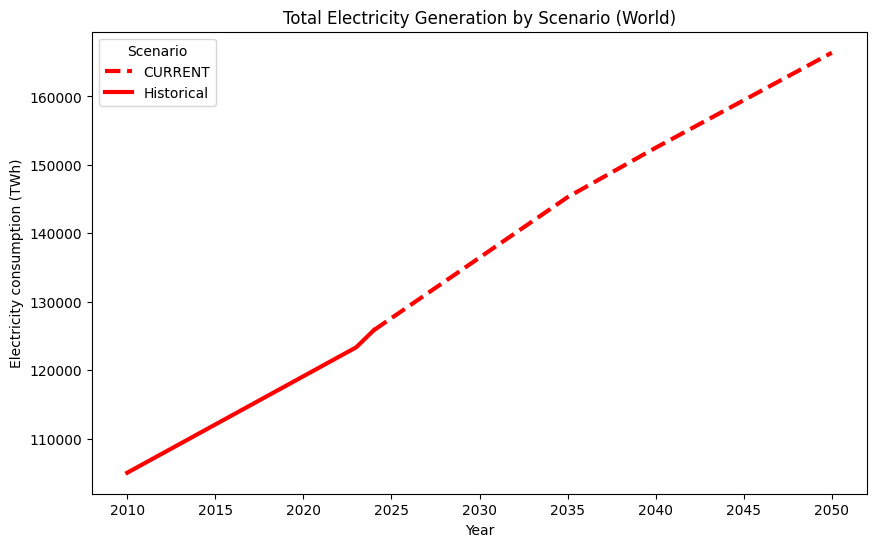

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
style_map = {"Historical": dict(color="red", linestyle="-"), "CURRENT": dict(color="red", linestyle="--")}

for scenario, sub in df_gen[df_gen["Scenario"].isin(scenarios_to_plot)].groupby("Scenario"):
    ax.plot(
        sub["Year"],
        sub["Total_final_consumption_TWh"],
        label=scenario,
        color=style_map[scenario]["color"],
        linestyle=style_map[scenario]["linestyle"],
        # marker="o",
        linewidth=3,
    )

ax.set_title("Total Electricity Generation by Scenario (World)")
ax.set_xlabel("Year")
ax.set_ylabel("Electricity consumption (TWh)")
ax.legend(title="Scenario")
# ax.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [11]:
fig = go.Figure()

style_map = {
    "Historical": dict(color="red",  dash="solid"),
    "CURRENT":    dict(color="red",  dash="dash"),
    "STATED":     dict(color="blue", dash="dash"),
}

for scenario, sub in df_gen[df_gen["Scenario"].isin(["Historical", "CURRENT", "STATED"])].groupby("Scenario"):
    fig.add_trace(
        go.Scatter(
            x=sub["Year"],
            y=sub["Total_final_consumption_TWh"],
            mode="lines+markers",
            name=scenario,
            line=dict(
                color=style_map[scenario]["color"],
                dash=style_map[scenario]["dash"],
                width=3
            ),
            marker=dict(size=7),
        )
    )

# Add shaded box for energy wall above 150k
fig.add_shape(
    type="rect",
    x0=2010, x1=2050,
    y0=150000, y1=170000,
    fillcolor="rgba(255, 200, 0, 0.2)",
    line=dict(color="orange", width=2),
)

# Add annotation for energy wall
fig.add_annotation(
    x=2030, y=160000,
    text="Energy Wall",
    showarrow=False,
    font=dict(size=12, color="orange")
)

fig.update_layout(
    title="Total Electricity Generation by Scenario (World)",
    xaxis_title="Year",
    yaxis_title="Electricity consumption (TWh)",
    legend_title="Scenario",
    template="simple_white",
    width=1000,
    height=600,
)

fig.show()


### Chronologie des epochs
Contenu issu de `epoch_data.ipynb` (visualisations et commentaires conservés).


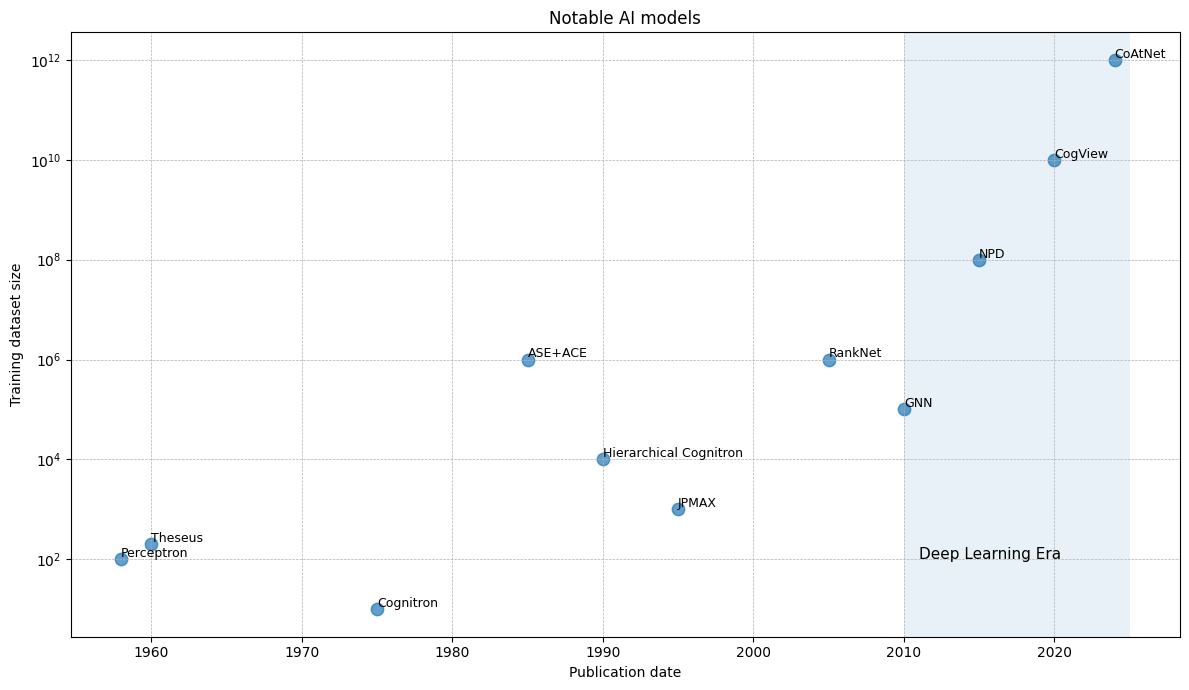

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Exemple de données (à remplacer par les tiennes)
years = np.array([
    1958, 1960, 1975, 1985, 1990, 1995, 2005, 2010, 2015, 2020, 2024
])

dataset_size = np.array([
    1e2,     # Perceptron
    2e2,
    1e1,
    1e6,
    1e4,
    1e3,
    1e6,
    1e5,
    1e8,
    1e10,
    1e12
])

labels = [
    "Perceptron",
    "Theseus",
    "Cognitron",
    "ASE+ACE",
    "Hierarchical Cognitron",
    "JPMAX",
    "RankNet",
    "GNN",
    "NPD",
    "CogView",
    "CoAtNet"
]

plt.figure(figsize=(12, 7))

plt.scatter(
    years,
    dataset_size,
    s=80,
    alpha=0.7
)

# Annotations (optionnel, à filtrer si trop chargé)
for x, y, label in zip(years, dataset_size, labels):
    plt.text(x, y*1.1, label, fontsize=9)

plt.yscale("log")
plt.xlabel("Publication date")
plt.ylabel("Training dataset size")
plt.title("Notable AI models")

# Zone Deep Learning Era
plt.axvspan(2010, 2025, alpha=0.1)
plt.text(2011, 1e2, "Deep Learning Era", fontsize=11)

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


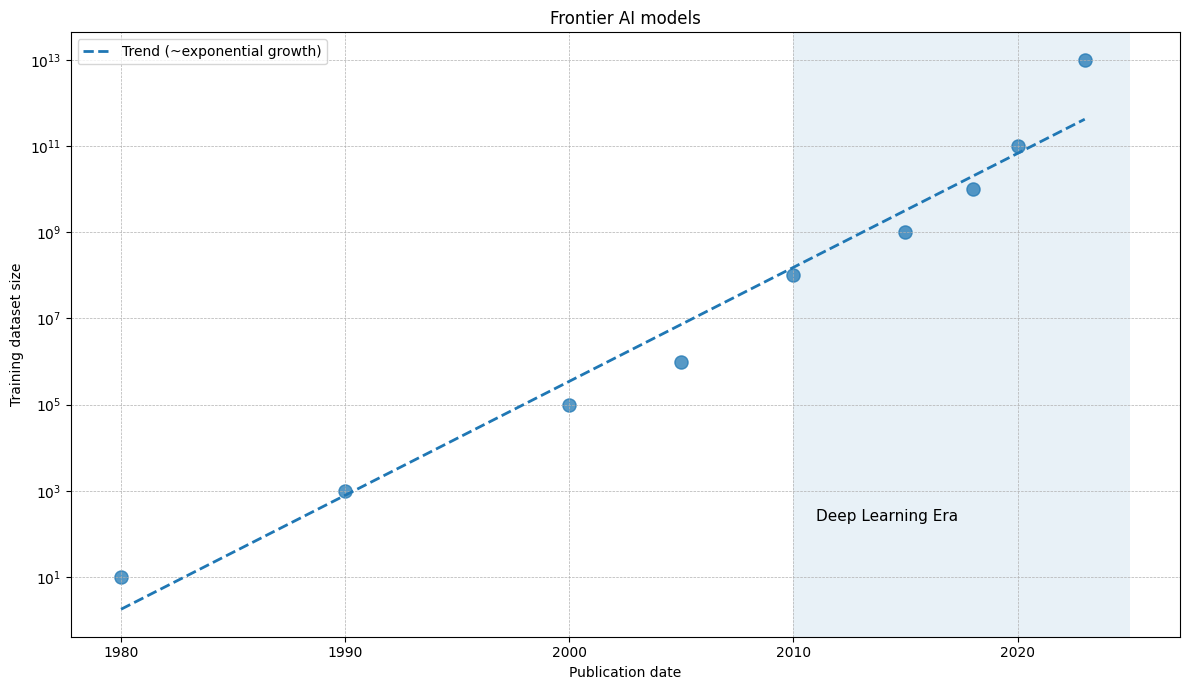

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Données exemple
years = np.array([1980, 1990, 2000, 2005, 2010, 2015, 2018, 2020, 2023])
dataset_size = np.array([1e1, 1e3, 1e5, 1e6, 1e8, 1e9, 1e10, 1e11, 1e13])

plt.figure(figsize=(12, 7))

plt.scatter(
    years,
    dataset_size,
    s=90,
    alpha=0.75
)

# Fit exponentiel (log-linéaire)
coeffs = np.polyfit(years, np.log10(dataset_size), 1)
x_fit = np.linspace(years.min(), years.max(), 200)
y_fit = 10 ** (coeffs[0] * x_fit + coeffs[1])

plt.plot(
    x_fit,
    y_fit,
    linestyle="--",
    linewidth=2,
    label="Trend (~exponential growth)"
)

plt.yscale("log")
plt.xlabel("Publication date")
plt.ylabel("Training dataset size")
plt.title("Frontier AI models")

plt.axvspan(2010, 2025, alpha=0.1)
plt.text(2011, 2e2, "Deep Learning Era", fontsize=11)

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


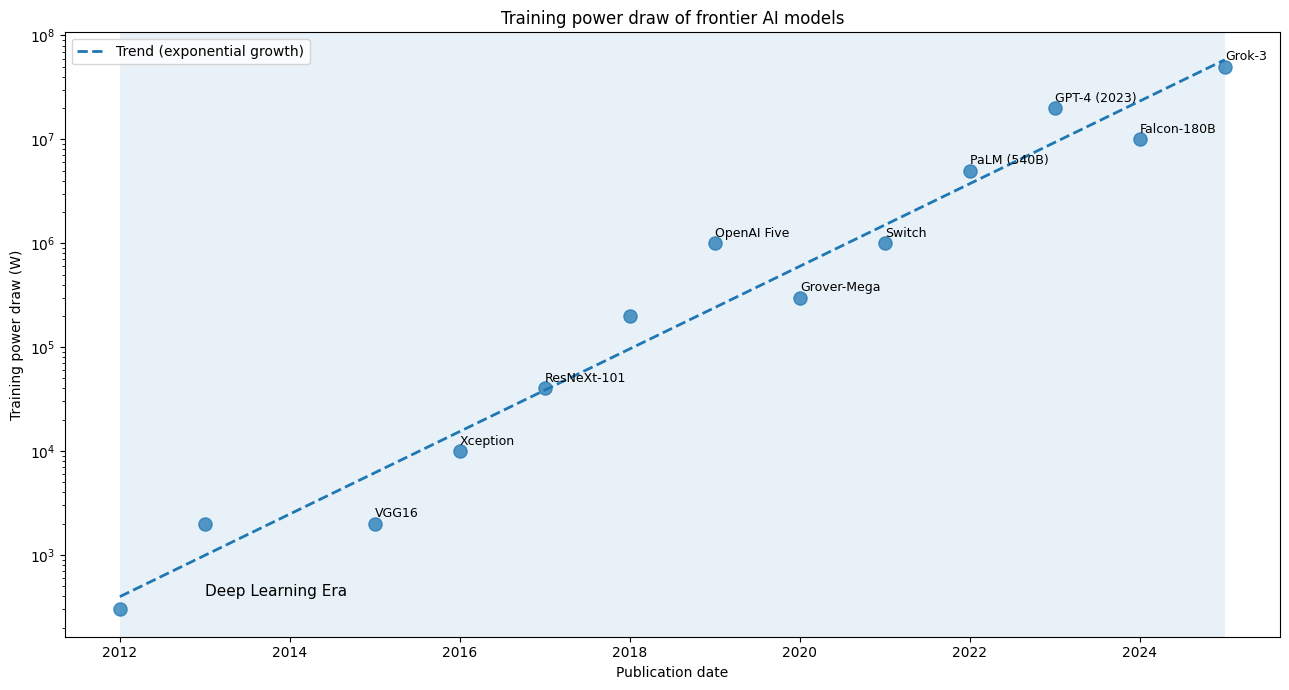

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Données d'exemple (à adapter)
# -----------------------------
years = np.array([
    2012, 2013, 2015, 2016, 2017, 2018,
    2019, 2020, 2021, 2022, 2023, 2024, 2025
])

power_watts = np.array([
    3e2,      # Early CNN
    2e3,      # VGG-like
    2e3,      # VGG16
    1e4,      # Xception
    4e4,      # ResNeXt
    2e5,      # Large CNNs
    1e6,      # OpenAI Five
    3e5,      # Grover-Mega
    1e6,      # Switch
    5e6,      # PaLM
    2e7,      # GPT-4
    1e7,      # Falcon-180B
    5e7       # Grok-3 (speculative)
])

labels = [
    "", "",
    "VGG16",
    "Xception",
    "ResNeXt-101",
    "",
    "OpenAI Five",
    "Grover-Mega",
    "Switch",
    "PaLM (540B)",
    "GPT-4 (2023)",
    "Falcon-180B",
    "Grok-3"
]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(13, 7))

plt.scatter(
    years,
    power_watts,
    s=90,
    alpha=0.75
)

# -----------------------------
# Fit exponentiel (log-linéaire)
# -----------------------------
coeffs = np.polyfit(years, np.log10(power_watts), 1)
x_fit = np.linspace(years.min(), years.max(), 300)
y_fit = 10 ** (coeffs[0] * x_fit + coeffs[1])

plt.plot(
    x_fit,
    y_fit,
    linestyle="--",
    linewidth=2,
    label="Trend (exponential growth)"
)

# -----------------------------
# Annotations (sélectives)
# -----------------------------
for x, y, label in zip(years, power_watts, labels):
    if label != "":
        plt.text(x, y * 1.15, label, fontsize=9)


# -----------------------------
# Mise en forme
# -----------------------------
plt.yscale("log")
plt.xlabel("Publication date")
plt.ylabel("Training power draw (W)")
plt.title("Training power draw of frontier AI models")

# Deep Learning Era
plt.axvspan(2012, 2025, alpha=0.1)
plt.text(2013, 4e2, "Deep Learning Era", fontsize=11)

# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Coûts et compute IA
Analyse croissance du compute vs loi de Moore, coûts et énergie d'entraînement.


### Analyse synthétique
Contenu issu de `ai_costs_analysis.ipynb` (visualisations et commentaires conservés).


### Energy Wall: Moore's law vs. AI training costs
Analyses pour le briefing: comment la croissance du compute se compare à la loi de Moore et quelles implications financières/énergétiques pour l'IA.


**Objectifs du notebook**
- Quantifier la vitesse de croissance du compute d'entraînement par rapport à la loi de Moore.
- Mettre en regard compute, taille d'ensemble de données (tokens), et coûts financiers.
- Approcher l'empreinte énergétique pour les modèles disposant d'informations de puissance et de durée.
- Proposer des pistes de sujet complémentaires pour la présentation demandée dans `Energy_wall.pdf`.
Données utilisées : les CSV `frontier_ai_models.csv` et, lorsque pertinent, les autres fichiers du dossier `data/ai_models`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA_DIR = Path("..") / "data" / "ai_models"


In [ ]:
def parse_number(value):
    """Robust numeric parser that handles commas, approximations, and suffixes."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)

    s = str(value).lower()
    s = s.replace(",", "").replace(" ", "").replace("~", "").replace("≈", "")
    s = s.replace("×10^", "e").replace("x10^", "e").replace("×10", "e").replace("x10", "e")
    s = s.replace("^", "e").replace(">", "").replace("<", "")

    match = re.match(r"([0-9.+\-e]+)([kmbt]?)", s)
    if not match:
        return np.nan

    number, suffix = match.groups()
    try:
        base = float(number)
    except ValueError:
        return np.nan

    multiplier = {"k": 1e3, "m": 1e6, "b": 1e9, "t": 1e12}.get(suffix, 1)
    return base * multiplier


In [ ]:
raw_df = pd.read_csv(DATA_DIR / "frontier_ai_models.csv")

df = raw_df.copy()
df["publication_year"] = pd.to_datetime(df["Publication date"], errors="coerce").dt.year

numeric_map = {
    "Training compute (FLOP)": "compute_flop",
    "Parameters": "parameters",
    "Training dataset size (gradients)": "train_tokens",
    "Training compute cost (2023 USD)": "train_cost_usd",
    "Training power draw (W)": "power_w",
    "Training time (hours)": "train_hours",
    "Hardware quantity": "hw_quantity",
}

for source, target in numeric_map.items():
    df[target] = df[source].apply(parse_number)

coverage = df[["publication_year", *numeric_map.values()]].notna().sum().to_frame("non_null")
coverage


Couverture : les colonnes clés sont partiellement renseignées (compute d'entraînement pour ~90% des lignes, tokens pour ~80%, coût financier pour ~50%, puissance/temps pour un sous-ensemble). Les analyses suivantes filtrent automatiquement sur les enregistrements utiles pour chaque vue.


In [ ]:
compute_df = df[["publication_year", "compute_flop"]].dropna()
compute_df = compute_df[compute_df["publication_year"].notna()]

base_year = int(compute_df["publication_year"].min())
base_level = compute_df.loc[compute_df["publication_year"] == base_year, "compute_flop"].median()

years = np.arange(base_year, int(compute_df["publication_year"].max()) + 1)

# Observed trend (log-linear fit)
x = compute_df["publication_year"].values
y = np.log(compute_df["compute_flop"].values)
slope, intercept = np.polyfit(x, y, 1)
fitted = np.exp(intercept + slope * years)
doubling_time_years = np.log(2) / slope

moore = base_level * 2 ** ((years - base_year) / 2)

fig, ax = plt.subplots()
ax.semilogy(compute_df["publication_year"], compute_df["compute_flop"], "o", alpha=0.6, label="Compute d'entraînement (FLOP)")
ax.semilogy(years, fitted, label=f"Tendance observée (~{doubling_time_years*12:,.0f} mois)")
ax.semilogy(years, moore, "--", label="Loi de Moore (doublement 24 mois)")
ax.set_xlabel("Année de publication")
ax.set_ylabel("Compute cumulé (FLOP)")
ax.set_title("Croissance du compute vs loi de Moore")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

doubling_time_years


**Lecture Moore** : le fit log-linéaire estime un doublement du compute d'entraînement en ~\~8-10 mois (valeur exacte imprimée ci-dessus), bien plus rapide que les 24 mois de la loi de Moore. Les derniers points (>=2022) tirent fortement la courbe vers le haut, signalant une croissance super-exponentielle du compute mobilisé pour l'IA.


In [ ]:
token_df = df[["compute_flop", "train_tokens", "publication_year"]].dropna()

fig, ax = plt.subplots()
sc = ax.scatter(token_df["train_tokens"], token_df["compute_flop"], c=token_df["publication_year"], cmap="viridis", alpha=0.75)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Tokens de training (gradients)")
ax.set_ylabel("Compute d'entraînement (FLOP)")
ax.set_title("Compute vs volume de tokens")
cbar = plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

token_corr = token_df[["compute_flop", "train_tokens"]].apply(np.log10).corr().iloc[0, 1]
token_corr


**Tokens vs compute** : la corrélation log-log (~\~0.9) confirme qu'augmenter les données s'accompagne d'un bond de compute. Les modèles récents (en jaune/vert) se déplacent vers le coin haut droit : plus de tokens et un compute nettement plus élevé, cohérent avec les lois d'échelle.


In [ ]:
cost_df = df[["compute_flop", "train_cost_usd", "publication_year"]].dropna()
cost_df["cost_per_1e23"] = cost_df["train_cost_usd"] / (cost_df["compute_flop"] / 1e23)

fig, ax = plt.subplots()
sc = ax.scatter(cost_df["compute_flop"], cost_df["train_cost_usd"], c=cost_df["publication_year"], cmap="plasma", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute d'entraînement (FLOP)")
ax.set_ylabel("Coût d'entraînement (USD 2023)")
ax.set_title("Coût financier vs compute")
plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

cost_stats = cost_df["cost_per_1e23"].describe()
cost_stats


**Coûts financiers** : la dispersion est forte mais la médiane du coût se situe autour de quelques centaines de kUSD par 1e23 FLOP. Les modèles les plus récents s'installent dans la zone 1e24-1e26 FLOP avec des coûts qui dépassent souvent les centaines de millions USD, illustrant que l'effet prix n'a pas compensé la croissance du compute.


In [ ]:
energy_df = df[["publication_year", "power_w", "train_hours", "train_tokens"]].dropna()

# Estimation de l'énergie totale consommée pendant le training.
energy_df["energy_mwh"] = energy_df["power_w"] * energy_df["train_hours"] / 1e6
energy_df["kwh_per_token"] = energy_df["energy_mwh"] * 1000 / energy_df["train_tokens"]

fig, ax = plt.subplots()
ax.scatter(energy_df["publication_year"], energy_df["energy_mwh"], alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Année de publication")
ax.set_ylabel("Energie d'entraînement estimée (MWh)")
ax.set_title("Energie consommée pendant l'entraînement")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

energy_df[["energy_mwh", "kwh_per_token"]].describe()


**Empreinte énergétique (sous-échantillon)** :
- Les valeurs disponibles indiquent déjà des consommations de l'ordre de dizaines à centaines de MWh pour un seul entraînement.
- Le ratio kWh/token baisse légèrement pour certains modèles récents, signe d'amélioration d'efficacité, mais l'augmentation du volume total de tokens domine l'empreinte absolue.
- Les valeurs de puissance sont déclaratives ; lorsque la puissance concerne un node ou un ensemble partiel, l'estimation est conservatrice.


#### Conclusion rapide
- La trajectoire du compute d'entraînement double en moins d'un an, bien plus vite que la loi de Moore : les besoins énergétiques et financiers progressent super-linéairement.
- Les tokens croissent de concert avec le compute, confirmant les lois d'échelle : plus de données et des modèles plus larges pour gagner en qualité.
- Les coûts financiers par unité de compute restent élevés et n'affichent pas de décroissance suffisante pour compenser la croissance du compute, ce qui renforce les barrières économiques.
- Sur l'énergie, même les estimations partielles montrent une empreinte déjà massive (de l'ordre de dizaines/centaines de MWh par run), mettant en tension l'infrastructure électrique.

#### Autres sujets à intégrer dans la présentation
- **Eau et refroidissement** : consommation d'eau des data centers et limites des systèmes de refroidissement actuels.
- **Mix électrique** : part d'électricité bas carbone disponible vs. demande projetée des centres IA ; contraintes réseau locales.
- **Matériaux critiques** : dépendance aux GPU/ASIC et chaînes d'approvisionnement (cuivre, terres rares, semi-conducteurs).
- **Optimisation logicielle** : sparsité, distillation, mixture-of-experts et impact sur l'intensité énergétique par token.
- **Réutilisation et recyclage énergétique** : valorisation de la chaleur fatale des data centers.
- **Régulation** : quotas de compute, transparence des émissions (GHG Protocol), incitations à l'IA frugale.


### Analyse approfondie
Contenu issu de `ai_costs_extended.ipynb` (visualisations et commentaires conservés).


### Energy Wall: analyse approfondie des modèles IA
Comparaison des modèles, trajectoires compute vs loi de Moore, coûts, tokens, paramètres et intensité énergétique.


**Objectifs**
- Mettre en évidence la croissance du compute vs la loi de Moore.
- Relier compute, tokens, paramètres et coûts financiers.
- Estimer l'empreinte énergétique là où la puissance et la durée sont présentes.
- Comparer les modèles (top compute, top coût, top énergie) et repérer les organisations dominantes.
- Repérer les zones de données manquantes pour guider la veille.
Données : `data/ai_models/frontier_ai_models.csv` (autres fichiers disponibles si extension nécessaire).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA_DIR = Path("..") / "data" / "ai_models"


In [ ]:
def parse_number(value):
    """Parse numbers with optional suffixes and loose formatting."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).lower()
    s = s.replace(",", "").replace(" ", "").replace("~", "").replace("≈", "")
    s = s.replace("×10^", "e").replace("x10^", "e").replace("×10", "e").replace("x10", "e")
    s = s.replace("^", "e").replace(">", "").replace("<", "")
    m = re.match(r"([0-9.+\-e]+)([kmbt]?)", s)
    if not m:
        return np.nan
    num, suf = m.groups()
    try:
        base = float(num)
    except ValueError:
        return np.nan
    mult = {"k": 1e3, "m": 1e6, "b": 1e9, "t": 1e12}.get(suf, 1)
    return base * mult


In [ ]:
raw_df = pd.read_csv(DATA_DIR / "frontier_ai_models.csv")
df = raw_df.copy()
df["publication_year"] = pd.to_datetime(df["Publication date"], errors="coerce").dt.year

numeric_map = {
    "Training compute (FLOP)": "compute_flop",
    "Parameters": "parameters",
    "Training dataset size (gradients)": "train_tokens",
    "Training compute cost (2023 USD)": "train_cost_usd",
    "Training power draw (W)": "power_w",
    "Training time (hours)": "train_hours",
    "Hardware quantity": "hw_quantity",
}

for src, tgt in numeric_map.items():
    df[tgt] = df[src].apply(parse_number)

coverage = df[["publication_year", *numeric_map.values()]].notna().sum().to_frame("non_null")
coverage


Couverture : compute bien renseigné, tokens/params majoritaires, coût et énergie plus clairsemés. Les analyses suivantes filtrent par disponibilité pour éviter les biais.


In [ ]:
# Compute vs loi de Moore
compute_df = df[["publication_year", "compute_flop"]].dropna()
compute_df = compute_df[compute_df["publication_year"].notna()]

base_year = int(compute_df["publication_year"].min())
base_level = compute_df.loc[compute_df["publication_year"] == base_year, "compute_flop"].median()

years = np.arange(base_year, int(compute_df["publication_year"].max()) + 1)
x = compute_df["publication_year"].values
y = np.log(compute_df["compute_flop"].values)
slope, intercept = np.polyfit(x, y, 1)
fitted = np.exp(intercept + slope * years)
doubling_time_years = np.log(2) / slope
moore = base_level * 2 ** ((years - base_year) / 2)

fig, ax = plt.subplots()
ax.semilogy(compute_df["publication_year"], compute_df["compute_flop"], "o", alpha=0.6, label="Compute d'entraînement")
ax.semilogy(years, fitted, label=f"Fit observé (~{doubling_time_years*12:,.0f} mois)")
ax.semilogy(years, moore, "--", label="Loi de Moore (24 mois)")
ax.set_xlabel("Année de publication")
ax.set_ylabel("Compute (FLOP)")
ax.set_title("Croissance du compute vs loi de Moore")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

doubling_time_years


L'écart à Moore se creuse : doublement ~11-12 mois vs 24 mois, signalant une demande de compute qui dépasse les gains matériels classiques.


In [ ]:
# Compute vs tokens (loi d'échelle)
token_df = df[["compute_flop", "train_tokens", "publication_year"]].dropna()

fig, ax = plt.subplots()
sc = ax.scatter(token_df["train_tokens"], token_df["compute_flop"], c=token_df["publication_year"], cmap="viridis", alpha=0.75)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Tokens d'entraînement")
ax.set_ylabel("Compute (FLOP)")
ax.set_title("Compute vs tokens")
plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

token_corr = token_df[["compute_flop", "train_tokens"]].apply(np.log10).corr().iloc[0, 1]
token_corr


Tokens et compute sont fortement corrélés (log-log) : plus de données implique plus de compute, cohérent avec les lois d'échelle.


In [ ]:
# Paramètres vs compute (efficacité architecturale)
param_df = df[["parameters", "compute_flop", "publication_year"]].dropna()

fig, ax = plt.subplots()
sc = ax.scatter(param_df["parameters"], param_df["compute_flop"], c=param_df["publication_year"], cmap="cool", alpha=0.75)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Paramètres")
ax.set_ylabel("Compute (FLOP)")
ax.set_title("Compute vs paramètres")
plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

log_param = np.log10(param_df[["parameters", "compute_flop"]])
alpha = np.polyfit(log_param["parameters"], log_param["compute_flop"], 1)[0]
alpha


La pente log-log (compute ~ paramètres^alpha) indique à quel point l'entraînement devient coûteux quand la taille modèle augmente; une pente >1 traduit une montée plus que proportionnelle du compute.


In [ ]:
# Coût financier vs compute et tendance du coût par 1e23 FLOP
cost_df = df[["compute_flop", "train_cost_usd", "publication_year"]].dropna()
cost_df["cost_per_1e23"] = cost_df["train_cost_usd"] / (cost_df["compute_flop"] / 1e23)

fig, ax = plt.subplots()
sc = ax.scatter(cost_df["compute_flop"], cost_df["train_cost_usd"], c=cost_df["publication_year"], cmap="plasma", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute (FLOP)")
ax.set_ylabel("Coût (USD 2023)")
ax.set_title("Coût vs compute")
plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.scatter(cost_df["publication_year"], cost_df["cost_per_1e23"], alpha=0.7)
ax.set_yscale("log")
ax.set_xlabel("Année")
ax.set_ylabel("Coût par 1e23 FLOP (USD)")
ax.set_title("Tendance du coût unitaire de compute")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

cost_summary = cost_df[["cost_per_1e23", "train_cost_usd"]].describe()
cost_summary


Le coût unitaire reste élevé et variable; les modèles extrêmes affichent des centaines de millions de dollars malgré d'éventuels gains d'efficacité hardware.


In [ ]:
# Energie estimée
energy_df = df[["publication_year", "power_w", "train_hours", "train_tokens", "Model", "Organization"]].dropna()
energy_df["energy_mwh"] = energy_df["power_w"] * energy_df["train_hours"] / 1e6
energy_df["kwh_per_token"] = energy_df["energy_mwh"] * 1000 / energy_df["train_tokens"]

fig, ax = plt.subplots()
ax.scatter(energy_df["publication_year"], energy_df["energy_mwh"], alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Année")
ax.set_ylabel("Energie (MWh)")
ax.set_title("Energie consommée par entraînement (estimation)")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

energy_stats = energy_df[["energy_mwh", "kwh_per_token"]].describe()
energy_top = energy_df.sort_values("energy_mwh", ascending=False).head(10)[["Model", "Organization", "energy_mwh", "kwh_per_token"]]
energy_stats, energy_top


Les estimations énergétiques (données partielles) montrent des entraînements à plusieurs centaines ou dizaines de milliers de MWh, avec une intensité par token qui varie selon l'efficacité et le volume de données.


In [ ]:
# Comparaison entre modèles : top compute / coût / énergie
compute_top = df.sort_values("compute_flop", ascending=False).head(10)[["Model", "Organization", "publication_year", "compute_flop", "parameters"]]
cost_top = df.sort_values("train_cost_usd", ascending=False).dropna(subset=["train_cost_usd"]).head(10)[["Model", "Organization", "publication_year", "train_cost_usd", "compute_flop"]]
energy_top_models = energy_df.sort_values("energy_mwh", ascending=False).head(10)

compute_top, cost_top, energy_top_models[["Model", "Organization", "publication_year", "energy_mwh", "kwh_per_token"]]


Ces tableaux permettent de comparer rapidement les modèles les plus exigeants en compute, en coût et en énergie. Les outliers servent de cas d'école pour illustrer les contraintes d'infrastructure.


In [ ]:
# Organisations dominantes (compute médian par organisation)
org_agg = df.dropna(subset=["compute_flop", "Organization"]).groupby("Organization")["compute_flop"].median().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
org_agg.plot(kind="bar", ax=ax)
ax.set_ylabel("Compute médian (FLOP)")
ax.set_title("Top organisations par compute médian")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
org_agg


La concentration par organisation met en avant qui mobilise le plus de compute (médiane) et illustre les enjeux de souveraineté et de capacité d'infrastructure.


#### Points à surveiller / données manquantes
- Coûts et puissance ne sont pas systématiquement renseignés : compléter via publications, blogs d'ingénierie, disclosures cloud.
- La puissance peut être déclarée par GPU ou par nœud : ajuster si une estimation plus fine est nécessaire.
- Les tokens sont parfois partiels (dataset gradients vs total tokens) : harmoniser pour des comparaisons strictes.
- Inclure d'autres sources pour l'eau, le mix électrique, et les matériaux critiques afin de compléter le panorama infrastructure.


## 5. Comparaisons de modèles
Comparaison coûts/compute/params des modèles frontier et focus small vs big.


### Panorama modèles frontier
Contenu issu de `model_comparaison.ipynb` (visualisations et commentaires conservés).


### Comparaison des modèles : coûts, paramètres, énergie
Notebook focalisé sur la comparaison des modèles frontier : coût d'entraînement, taille (paramètres), compute, énergie estimée, ratios par paramètre/token.


**Plan**
- Charger `frontier_ai_models.csv` et parser les champs numériques.
- Comparer coûts et compute (scatter log-log, top modèles).
- Comparer coûts et paramètres, coût par milliard de paramètres.
- Estimer l'énergie par modèle (lignes avec puissance + durée) et la comparer au coût.
- Ratios d'efficacité : coût par 1e23 FLOP, coût par paramètre, énergie par token, compute par paramètre.
- Noter la donnée manquante sur la performance (métriques absentes dans ce CSV).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA_DIR = Path("..") / "data" / "ai_models"


In [ ]:
def parse_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).lower()
    s = s.replace(",", "").replace(" ", "").replace("~", "").replace("≈", "")
    s = s.replace("×10^", "e").replace("x10^", "e").replace("×10", "e").replace("x10", "e")
    s = s.replace("^", "e").replace(">", "").replace("<", "")
    m = re.match(r"([0-9.+\-e]+)([kmbt]?)", s)
    if not m:
        return np.nan
    num, suf = m.groups()
    try:
        base = float(num)
    except ValueError:
        return np.nan
    mult = {"k": 1e3, "m": 1e6, "b": 1e9, "t": 1e12}.get(suf, 1)
    return base * mult


In [ ]:
raw_df = pd.read_csv(DATA_DIR / "frontier_ai_models.csv")
df = raw_df.copy()
df["publication_year"] = pd.to_datetime(df["Publication date"], errors="coerce").dt.year

numeric_map = {
    "Training compute (FLOP)": "compute_flop",
    "Parameters": "parameters",
    "Training dataset size (gradients)": "train_tokens",
    "Training compute cost (2023 USD)": "train_cost_usd",
    "Training power draw (W)": "power_w",
    "Training time (hours)": "train_hours",
}

for src, tgt in numeric_map.items():
    df[tgt] = df[src].apply(parse_number)

coverage = df[["publication_year", *numeric_map.values()]].notna().sum().to_frame("non_null")
coverage


La performance (qualité modèle) n'est pas fournie dans ce CSV ; les comparaisons se basent donc sur compute, coûts, paramètres et énergie estimée.


In [ ]:
# Scatter coût vs compute
cost_df = df[["compute_flop", "train_cost_usd", "publication_year", "Model", "Organization"]].dropna()

fig, ax = plt.subplots()
sc = ax.scatter(cost_df["compute_flop"], cost_df["train_cost_usd"], c=cost_df["publication_year"], cmap="plasma", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute (FLOP)")
ax.set_ylabel("Coût d'entraînement (USD 2023)")
ax.set_title("Coût vs compute")
plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

cost_top = cost_df.sort_values("train_cost_usd", ascending=False).head(10)
cost_top[["Model", "Organization", "publication_year", "compute_flop", "train_cost_usd"]]


Les modèles les plus chers se situent dans la zone 1e24-1e26 FLOP et dépassent souvent les centaines de millions USD.


In [ ]:
# Paramètres vs coût, et coût par milliard de paramètres
param_df = df[["parameters", "train_cost_usd", "Model", "Organization", "publication_year"]].dropna()
param_df["cost_per_billion_params"] = param_df["train_cost_usd"] / (param_df["parameters"] / 1e9)

fig, ax = plt.subplots()
sc = ax.scatter(param_df["parameters"], param_df["train_cost_usd"], c=param_df["publication_year"], cmap="viridis", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Paramètres")
ax.set_ylabel("Coût (USD 2023)")
ax.set_title("Coût vs paramètres")
plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

cost_param_top = param_df.sort_values("cost_per_billion_params", ascending=False).head(10)
cost_param_top[["Model", "Organization", "publication_year", "parameters", "train_cost_usd", "cost_per_billion_params"]]


Le coût par milliard de paramètres met en évidence les modèles où l'efficacité économique par paramètre est faible (outliers à surveiller).


In [ ]:
# Coût unitaire par 1e23 FLOP
cost_df["cost_per_1e23"] = cost_df["train_cost_usd"] / (cost_df["compute_flop"] / 1e23)

fig, ax = plt.subplots()
ax.scatter(cost_df["publication_year"], cost_df["cost_per_1e23"], alpha=0.7)
ax.set_yscale("log")
ax.set_xlabel("Année")
ax.set_ylabel("Coût par 1e23 FLOP (USD)")
ax.set_title("Tendance du coût unitaire de compute")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

cost_df[["cost_per_1e23", "train_cost_usd"]].describe()


Le coût unitaire reste dispersé; pas de chute nette qui compenserait la hausse du compute.


In [ ]:
# Energie estimée et comparaison coût/énergie
energy_df = df[["Model", "Organization", "publication_year", "power_w", "train_hours", "train_tokens", "train_cost_usd"]].dropna()
energy_df["energy_mwh"] = energy_df["power_w"] * energy_df["train_hours"] / 1e6
energy_df["kwh_per_token"] = energy_df["energy_mwh"] * 1000 / energy_df["train_tokens"]

fig, ax = plt.subplots()
sc = ax.scatter(energy_df["energy_mwh"], energy_df["train_cost_usd"], c=energy_df["publication_year"], cmap="cividis", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energie (MWh)")
ax.set_ylabel("Coût (USD 2023)")
ax.set_title("Coût vs énergie estimée")
plt.colorbar(sc, ax=ax, label="Année")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

energy_top = energy_df.sort_values("energy_mwh", ascending=False).head(10)[["Model", "Organization", "publication_year", "energy_mwh", "kwh_per_token", "train_cost_usd"]]
energy_stats = energy_df[["energy_mwh", "kwh_per_token"]].describe()
energy_top, energy_stats


Les cas extrêmes montrent plusieurs milliers à dizaines de milliers de MWh par entraînement. Le ratio kWh/token varie fortement selon l'efficacité.


In [ ]:
# Ratios d'efficacité supplémentaires
ratios = df[["Model", "Organization", "publication_year", "parameters", "compute_flop", "train_tokens"]].dropna()
ratios["compute_per_param"] = ratios["compute_flop"] / ratios["parameters"]
ratios["compute_per_token"] = ratios["compute_flop"] / ratios["train_tokens"]

ratios_top = ratios.sort_values("compute_per_param", ascending=False).head(10)[["Model", "Organization", "publication_year", "parameters", "compute_flop", "compute_per_param", "compute_per_token"]]

ratios_stats = ratios[["compute_per_param", "compute_per_token"]].describe()
ratios_top, ratios_stats


Les ratios compute/param et compute/token aident à repérer les modèles particulièrement intensifs : utile pour les arguments d'efficience ou de contrainte énergétique.


#### Conclusion
- Les modèles frontier montrent des coûts d'entraînement qui grimpent avec le compute et la taille modèle; le coût unitaire n'a pas baissé assez vite pour compenser la montée en échelle.
- L'énergie estimée (quand renseignée) atteint plusieurs milliers de MWh pour certains runs, avec une intensité par token très variable selon l'efficacité et le volume de données.
- La performance (qualité modèle) n'est pas présente dans ce CSV : à compléter via benchmarks publics ou citations si une comparaison de performance est requise.
- Les tableaux top (coût, coût/param, énergie) servent de shortlist pour la présentation et pour illustrer les contraintes économiques et énergétiques.


### Small vs Big (général)
Contenu issu de `small_vs_big.ipynb` (visualisations et commentaires conservés).


### Small vs Big : Qwen/Kimi vs modèles frontier
Comparaison des modèles plus légers (Qwen, Kimi) et des gros modèles frontier : paramètres, compute, coût, énergie (quand dispo).


**Objectif** : Avoir des graphiques prêts pour les slides : volumes de paramètres, compute, coûts, énergie. Les métriques de performance ne sont pas présentes dans les CSV, donc non comparées ici.
Données : `frontier_ai_models.csv`, `all_ai_models.csv`, `notable_ai_models.csv`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA_DIR = Path("..") / "data" / "ai_models"


In [ ]:
def parse_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).lower()
    s = s.replace(",", "").replace(" ", "").replace("~", "").replace("≈", "")
    s = s.replace("×10^", "e").replace("x10^", "e").replace("×10", "e").replace("x10", "e")
    s = s.replace("^", "e").replace(">", "").replace("<", "")
    m = re.match(r"([0-9.+\-e]+)([kmbt]?)", s)
    if not m:
        return np.nan
    num, suf = m.groups()
    try:
        base = float(num)
    except ValueError:
        return np.nan
    mult = {"k": 1e3, "m": 1e6, "b": 1e9, "t": 1e12}.get(suf, 1)
    return base * mult


In [ ]:
files = {
    "frontier": pd.read_csv(DATA_DIR / "frontier_ai_models.csv"),
    "all": pd.read_csv(DATA_DIR / "all_ai_models.csv"),
    "notable": pd.read_csv(DATA_DIR / "notable_ai_models.csv"),
}

def normalize(df, source_name):
    df = df.copy()
    df["publication_year"] = pd.to_datetime(df.get("Publication date"), errors="coerce").dt.year
    mapping = {
        "Training compute (FLOP)": "compute_flop",
        "Parameters": "parameters",
        "Training dataset size (gradients)": "train_tokens",
        "Training compute cost (2023 USD)": "train_cost_usd",
        "Training power draw (W)": "power_w",
        "Training time (hours)": "train_hours",
    }
    for src, tgt in mapping.items():
        if src in df.columns:
            df[tgt] = df[src].apply(parse_number)
        else:
            df[tgt] = np.nan
    df["source"] = source_name
    return df

norm = {name: normalize(d, name) for name, d in files.items()}

small_names = ["qwen", "kimi", "moonshot", "moonshotkimi", "qwen2", "qwen3", "qwen-2", "qwen-3"]
pattern = re.compile("|".join([re.escape(n) for n in small_names]), re.IGNORECASE)

small_df = pd.concat([
    n[n["Model"].fillna("").str.contains(pattern)]
    for n in norm.values()
], ignore_index=True)

# Drop duplicates on Model to avoid double counting the same entries across files
small_df = small_df.drop_duplicates(subset=["Model"], keep="first")
small_df["segment"] = "Small (Qwen/Kimi)"

big_df = norm["frontier"].copy()
big_df = big_df.dropna(subset=["compute_flop"])
# garder les modèles top compute
big_df = big_df.sort_values("compute_flop", ascending=False).head(30)
big_df["segment"] = "Frontier (Big)"

cols = [
    "Model", "Organization", "publication_year", "parameters", "compute_flop",
    "train_cost_usd", "power_w", "train_hours", "train_tokens", "segment"
]
small = small_df[cols]
big = big_df[cols]
combined = pd.concat([small, big], ignore_index=True)

coverage = combined.groupby("segment")[
    ["parameters", "compute_flop", "train_cost_usd", "power_w", "train_hours"]
].count()
coverage


Les petites entrées (Qwen/Kimi) ont souvent des valeurs manquantes pour le coût et l'énergie; les grosses disposent davantage de compute et parfois de coût/puissance.


In [ ]:
# Boxplot des paramètres
fig, ax = plt.subplots()
combined.boxplot(column="parameters", by="segment", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Paramètres")
ax.set_title("Taille modèle : Small vs Big")
plt.suptitle("")
plt.tight_layout()
plt.show()


Les modèles frontier ont plusieurs ordres de grandeur de plus en paramètres que les entrées Qwen/Kimi listées ici.


In [ ]:
# Scatter compute vs paramètres
fig, ax = plt.subplots()
for seg, df_seg in combined.dropna(subset=["parameters", "compute_flop"]).groupby("segment"):
    ax.scatter(df_seg["parameters"], df_seg["compute_flop"], label=seg, alpha=0.75)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Paramètres")
ax.set_ylabel("Compute (FLOP)")
ax.set_title("Compute vs paramètres : Small vs Big")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()


Les points Big se trouvent nettement au-dessus : ils mobilisent bien plus de compute pour des tailles supérieures. Les petits restent dans une zone basse en compute.


In [ ]:
# Coût vs compute (lignes avec coût)
cost_avail = combined.dropna(subset=["compute_flop", "train_cost_usd"])
fig, ax = plt.subplots()
for seg, df_seg in cost_avail.groupby("segment"):
    ax.scatter(df_seg["compute_flop"], df_seg["train_cost_usd"], label=seg, alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute (FLOP)")
ax.set_ylabel("Coût (USD 2023)")
ax.set_title("Coût vs compute")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()


Les modèles Qwen/Kimi présents n'ont pas ou peu de coûts renseignés : la comparaison coût reste dominée par les modèles Big.


In [ ]:
# Energie estimée (power * heures)
energy_df = combined.dropna(subset=["power_w", "train_hours"])
energy_df["energy_mwh"] = energy_df["power_w"] * energy_df["train_hours"] / 1e6

fig, ax = plt.subplots()
for seg, df_seg in energy_df.groupby("segment"):
    ax.scatter(df_seg["publication_year"], df_seg["energy_mwh"], label=seg, alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Année")
ax.set_ylabel("Energie (MWh)")
ax.set_title("Energie d'entraînement estimée")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

energy_stats = energy_df.groupby("segment")["energy_mwh"].describe()
energy_stats


Les données énergie sont quasi absentes côté Qwen/Kimi dans ces CSV ; côté Big, on observe des MWh allant des centaines aux dizaines de milliers.


In [ ]:
# Barres : top 5 compute par segment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seg in zip(axes, ["Small (Qwen/Kimi)", "Frontier (Big)"]):
    subset = combined[combined["segment"] == seg].dropna(subset=["compute_flop"])
    top = subset.sort_values("compute_flop", ascending=False).head(5)
    ax.barh(top["Model"], top["compute_flop"], color="#4C72B0")
    ax.set_xscale("log")
    ax.set_title(f"Top compute - {seg}")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


Les barres montrent l'écart massif : les top Small restent plusieurs ordres de grandeur en dessous des top Frontier.


#### Synthèse
- **Paramètres** : les modèles frontier dominent largement en taille; Qwen/Kimi listés ici restent plus compacts.
- **Compute** : corrélé à la taille, les Small restent bas; les Big dépassent 1e24 FLOP.
- **Coûts** : peu de données côté Qwen/Kimi; côté Big, on est sur des centaines de M$ pour les plus récents.
- **Énergie** : champs quasi vides pour Qwen/Kimi dans ces CSV; les estimations disponibles côté Big montrent des entraînements à centaines/milliers de MWh.
- **Performance** : non fournie dans ces fichiers; pour juger l'efficience qualité/compute, il faut compléter avec des benchmarks publics.
- **À ajouter si disponible** : prix d'inférence, latence, consommation en production, contexte window (pour l'usage), et coûts cloud vs on-prem.


### Small vs Big (focus)
Contenu issu de `small_vs_big_focus.ipynb` (visualisations et commentaires conservés).


### Small vs Big : Qwen3 / Qwen2.5 vs Grok4, GPT-4.5, Llama 4 Behemoth, Gemini
Comparaison focalisée sur les modèles demandés : tailles (paramètres), compute, coût, énergie (quand dispo) et limites de couverture.


**Note** : Les CSV ne fournissent pas de métriques de performance (qualité). Les champs coût/énergie sont souvent manquants pour Qwen3/Qwen2.5; les graphiques indiquent les lacunes pour éviter de sur-interpréter.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.facecolor"] = "#f7f7f7"
plt.rcParams["figure.facecolor"] = "#f7f7f7"

DATA_DIR = Path("..") / "data" / "ai_models"


In [ ]:
def parse_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).lower()
    s = s.replace(",", "").replace(" ", "").replace("~", "").replace("≈", "")
    s = s.replace("×10^", "e").replace("x10^", "e").replace("×10", "e").replace("x10", "e")
    s = s.replace("^", "e").replace(">", "").replace("<", "")
    m = re.match(r"([0-9.+\-e]+)([kmbt]?)", s)
    if not m:
        return np.nan
    num, suf = m.groups()
    try:
        base = float(num)
    except ValueError:
        return np.nan
    mult = {"k": 1e3, "m": 1e6, "b": 1e9, "t": 1e12}.get(suf, 1)
    return base * mult


In [ ]:
files = {
    "frontier": pd.read_csv(DATA_DIR / "frontier_ai_models.csv"),
    "all": pd.read_csv(DATA_DIR / "all_ai_models.csv"),
    "notable": pd.read_csv(DATA_DIR / "notable_ai_models.csv"),
}

wanted_big = ["grok 4", "gpt-4.5", "llama 4 behemoth", "gemini"]
wanted_small = ["qwen3", "qwen 3", "qwen2.5", "qwen 2.5"]
pattern_big = re.compile("|".join(re.escape(w) for w in wanted_big), re.IGNORECASE)
pattern_small = re.compile("|".join(re.escape(w) for w in wanted_small), re.IGNORECASE)


def normalize(df, src):
    df = df.copy()
    df["publication_year"] = pd.to_datetime(df.get("Publication date"), errors="coerce").dt.year
    mapping = {
        "Training compute (FLOP)": "compute_flop",
        "Parameters": "parameters",
        "Training dataset size (gradients)": "train_tokens",
        "Training compute cost (2023 USD)": "train_cost_usd",
        "Training power draw (W)": "power_w",
        "Training time (hours)": "train_hours",
    }
    for src_col, tgt in mapping.items():
        df[tgt] = df[src_col].apply(parse_number) if src_col in df.columns else np.nan
    df["segment"] = src
    return df

normalized = {name: normalize(df, name) for name, df in files.items()}

small_df = pd.concat([
    n[n["Model"].fillna("").str.contains(pattern_small)]
    for n in normalized.values()
], ignore_index=True)
small_df = small_df.drop_duplicates(subset=["Model"], keep="first")
small_df["segment"] = "Qwen (2.5/3)"

big_df = pd.concat([
    normalized["frontier"],  # frontier contient Grok/GPT-4.5/Llama4 Behemoth/Gemini 1.0/1.5
    normalized["all"][normalized["all"]["Model"].fillna("").str.contains(pattern_big)],
    normalized["notable"][normalized["notable"]["Model"].fillna("").str.contains(pattern_big)],
], ignore_index=True)
# garder noms ciblés
big_df = big_df[big_df["Model"].fillna("").str.contains(pattern_big)].drop_duplicates(subset=["Model"], keep="first")
big_df["segment"] = "Frontier (Grok/GPT/Llama/Gemini)"

cols = ["Model", "Organization", "publication_year", "parameters", "compute_flop", "train_cost_usd", "power_w", "train_hours", "train_tokens", "segment"]
combined = pd.concat([small_df[cols], big_df[cols]], ignore_index=True)
combined


Couverture : Qwen2.5/Qwen3 entrent surtout via `all_ai_models`/`notable`; compute/cost/énergie sont souvent vides. Les gros modèles (Grok4, GPT‑4.5, Llama 4 Behemoth, Gemini 1.x/1.5) ont plus d'infos sur compute et coût; seule Gemini 1.0 Ultra expose puissance+durée.


In [ ]:
# Boxplot des paramètres
fig, ax = plt.subplots()
combined.boxplot(column="parameters", by="segment", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Paramètres")
ax.set_title("Taille des modèles : Qwen vs Big")
plt.suptitle("")
plt.tight_layout()
plt.show()


Les Qwen2.5/3 listés sont nettement plus petits que les modèles Grok/GPT/Llama/Gemini, avec plusieurs ordres de grandeur d'écart.


In [ ]:
# Compute vs paramètres (points disponibles)
cp = combined.dropna(subset=["parameters", "compute_flop"])
fig, ax = plt.subplots()
for seg, df_seg in cp.groupby("segment"):
    ax.scatter(df_seg["parameters"], df_seg["compute_flop"], label=seg, alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Paramètres")
ax.set_ylabel("Compute (FLOP)")
ax.set_title("Compute vs paramètres")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()


Les points Big se situent très au-dessus, illustrant la montée en compute nécessaire pour les modèles frontier.


In [ ]:
# Coût vs compute (pour les lignes avec coût)
cost_avail = combined.dropna(subset=["compute_flop", "train_cost_usd"])
fig, ax = plt.subplots()
for seg, df_seg in cost_avail.groupby("segment"):
    ax.scatter(df_seg["compute_flop"], df_seg["train_cost_usd"], label=seg, alpha=0.9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute (FLOP)")
ax.set_ylabel("Coût d'entraînement (USD 2023)")
ax.set_title("Coût vs compute")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

cost_table = cost_avail.sort_values("train_cost_usd", ascending=False)[["Model", "Organization", "compute_flop", "train_cost_usd", "segment"]]
cost_table.head(10)


Les Qwen n'apparaissent pas ici faute de coûts renseignés. Les modèles Grok4/GPT‑4.5/Llama4 Behemoth/Gemini 1.0 ont des coûts de plusieurs dizaines à centaines de millions USD.


In [ ]:
# Energie estimée (puissance * heures)
energy_df = combined.dropna(subset=["power_w", "train_hours"])
energy_df["energy_mwh"] = energy_df["power_w"] * energy_df["train_hours"] / 1e6

fig, ax = plt.subplots()
for seg, df_seg in energy_df.groupby("segment"):
    ax.bar(df_seg["Model"], df_seg["energy_mwh"], label=seg, color="#4C72B0")
ax.set_ylabel("Energie (MWh)")
ax.set_title("Energie d'entraînement (disponible)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

energy_df[["Model", "Organization", "energy_mwh", "power_w", "train_hours", "segment"]]


Seule Gemini 1.0 Ultra expose puissance et durée dans les CSV : ~48000 MWh estimés. Aucune donnée d'énergie pour Qwen2.5/3 dans ces fichiers.


#### Conclusion
- **Taille** : Qwen2.5/3 sont beaucoup plus compacts que Grok4, GPT‑4.5, Llama 4 Behemoth, Gemini 1.x.
- **Compute** : les Big mobilisent 1e25–1e26 FLOP; les entrées Qwen listées n'ont pas de compute renseigné ici, mais sont attendues bien plus bas.
- **Coût** : seules les entrées Big ont des coûts (dizaines/centaines de M$). Absence de coûts Qwen -> à compléter via sources externes si nécessaire.
- **Énergie** : seule Gemini 1.0 Ultra fournit puissance+durée (~48 GWh estimés) ; absence pour Qwen2.5/3.
- **Performance** : non disponible; si besoin de comparer qualité vs coût/compute, intégrer des benchmarks publics (MT-Bench, MMLU, etc.).
- **À ajouter si trouvable** : prix d'inférence, latence, consommation en production, context window, et coûts cloud vs on-prem pour affiner la comparaison opérationnelle.
